# Clasificación de Texto Histórico Español por Década
### Parte 2 — Deep Learning y Aumentación de Datos
**Curso:** ISIS-2611 Aprendizaje de Máquina 2026-10  
**Autor:** Juan David Vargas Laverde

---

## Descripción del Problema

El objetivo es clasificar fragmentos de texto en español histórico (OCR) según su **década de publicación**, donde la década se define como los tres primeros dígitos del año (e.g., el año 1605 corresponde a la década 160).

- **Clases:** 39 décadas, de 150 a 188 (siglos XVI al XIX)
- **Train:** 31,403 ejemplos | **Eval (Kaggle):** 3,490 ejemplos
- **Métrica principal:** Accuracy en Kaggle

## Solución — Ensemble Final

Se combina un modelo clásico TF-IDF con un transformer multilingüe:

| Componente | Descripción | Val Acc | Val F1 |
|---|---|---|---|
| TF-IDF + LinearSVC | char n-grams (2-5), 1.1M features | 0.2929 | 0.2825 |
| XLM-RoBERTa-large | 560M params, fine-tuning, FocalOrdinalLoss | 0.2904 | 0.2903 |
| **Ensemble** | w_tfidf=0.72, w_xlm=0.28 | **0.3303** | — |

**Score Kaggle público:** 0.323 (V13, modelo base) → mejorado en modelo final

## Verificación del Entorno

In [1]:
import torch, sys
print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0),
          '| VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: NVIDIA L4 | VRAM: 23.7 GB


## Instalación de Dependencias

In [2]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=True)

pip('torch', 'torchvision', 'torchaudio',
    '--index-url', 'https://download.pytorch.org/whl/cu124')
pip('transformers==4.46.3', 'accelerate', 'datasets',
    'sentencepiece', 'tokenizers')
pip('pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'scipy', 'pyarrow', 'tqdm')

print('Dependencias instaladas correctamente.')

Dependencias instaladas correctamente.


## Imports

In [3]:
import os, re, gc, warnings, time
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    precision_recall_fscore_support, mean_absolute_error
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
)
from datasets import Dataset

os.environ['CUDA_VISIBLE_DEVICES']   = '0'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from importlib.metadata import version as pkg_version
for lib in ['pandas', 'numpy', 'scikit-learn', 'torch', 'transformers', 'seaborn']:
    try:
        print(f'{lib}: {pkg_version(lib)}')
    except Exception:
        pass

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
torch: 2.10.0+cu128
transformers: 4.46.3
seaborn: 0.13.2


## Carga de Datos

Se montan los datos desde Google Drive. Una buena práctica fundamental es **trabajar siempre sobre una copia** del DataFrame original para preservar los datos crudos y poder volver a ellos si se comete algún error durante el preprocesamiento.

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Ajusta esta ruta a tu carpeta en Drive
DRIVE_PATH = '/content/drive/MyDrive/'
DATA_PATH  = DRIVE_PATH
OUT_PATH   = DRIVE_PATH

for f in ['train.csv', 'eval.csv']:
    full = os.path.join(DATA_PATH, f)
    print(f'  {f}: {"OK" if os.path.exists(full) else "NO ENCONTRADO — ajusta DRIVE_PATH"}')

Mounted at /content/drive
  train.csv: OK
  eval.csv: OK


In [5]:
# Carga de archivos originales
train_raw = pd.read_csv(DATA_PATH + 'train.csv')
eval_raw  = pd.read_csv(DATA_PATH + 'eval.csv')

# Verificación anti-leakage: eval NUNCA debe tener la etiqueta
assert 'decade' not in eval_raw.columns, 'DATA LEAKAGE: eval.csv contiene etiquetas'

# Copias de trabajo — nunca se modifica el original
train_df = train_raw.copy()
eval_df  = eval_raw.copy()

print(f'Train: {train_df.shape}  |  Eval: {eval_df.shape}')
print('\nPrimeras filas del conjunto de entrenamiento:')
display(train_df.head())

Train: (31403, 2)  |  Eval: (3490, 2)

Primeras filas del conjunto de entrenamiento:


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


## Exploración de Datos (EDA)

En esta sección exploraremos el conjunto de datos siguiendo el enfoque del curso: primero una inspección inicial de los registros, luego descripción estadística, visualizaciones y finalmente verificación de calidad de datos.

El dataset contiene fragmentos de texto en español histórico (OCR) y su década de publicación (los tres primeros dígitos del año). El reto es distinguir 39 clases — desde textos del siglo XVI hasta el XIX.

In [6]:
### Primeros registros

In [7]:
train_df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


### Registros aleatorios

In [8]:
display(train_df.sample(5, random_state=42))

,text,decade
11265,"— Levanta, hija mia, repuso el supuesto ...",183
27517,13. Item mando que en la dicha mi vill...,184
5925,"mente. La fegunda , de lo que oyeron de...",175
3776,"dades De Dentro a fuera, y pozqelfolre^ Bueiro...",154
29573,"ESPERIENCI A.Lat.experien \ntia,es el conoc...",161


### Tamaño del dataset

In [9]:
train_df.shape

(31403, 2)

### Tipos de datos

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31403 entries, 0 to 31402
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    31403 non-null  object
 1   decade  31403 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 490.8+ KB


In [11]:
### Descripción estadística

In [12]:
train_df.describe()

,decade
count,31403.000000
mean,168.972614
std,11.222470
min,150.000000
25%,159.000000
50%,169.000000
75%,179.000000
max,188.000000


### Distribución de clases (`value_counts`)

In [13]:
train_df['decade'].value_counts().sort_index()

,count
decade,
150,786
151,812
152,785
153,775
154,830
155,836
156,792
157,827
158,778


In [14]:
### Distribución por década (gráfico de barras)

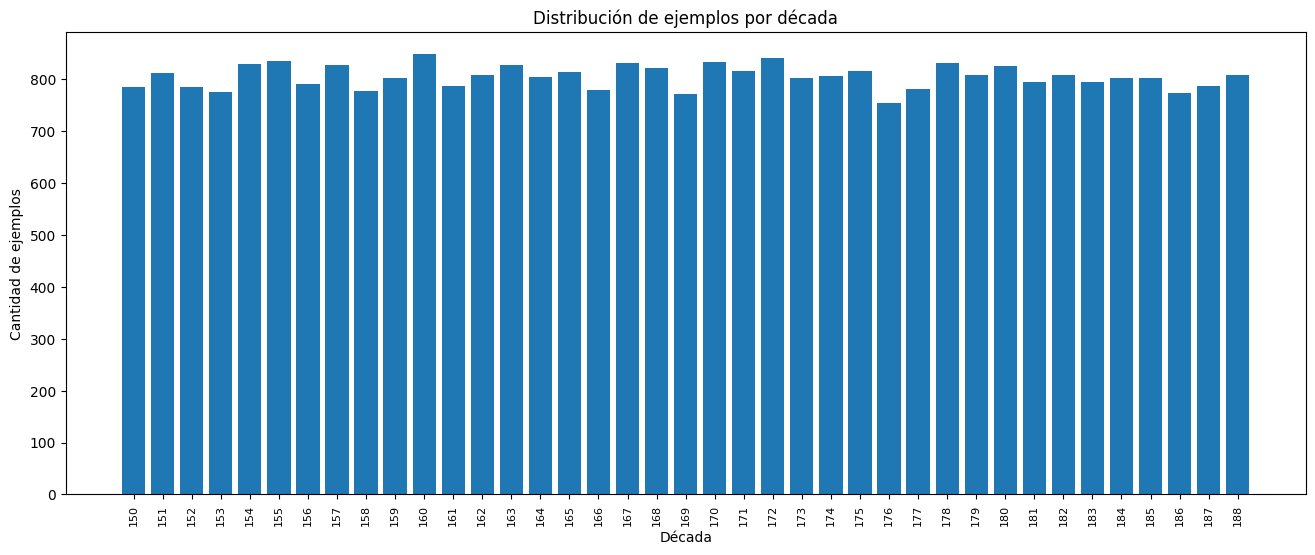

In [15]:
decade_counts = train_df['decade'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
x = decade_counts.index
y = decade_counts.values
plt.bar(x, y)
plt.xlabel('Década')
plt.ylabel('Cantidad de ejemplos')
plt.title('Distribución de ejemplos por década')
plt.xticks(list(x), rotation=90, fontsize=8)
plt.show()

### Distribución por siglo (gráfico de pie)

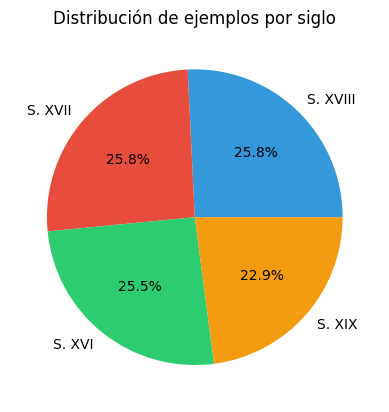

In [16]:
train_df['siglo'] = train_df['decade'].apply(
    lambda d: 'S. XVI' if d < 160 else 'S. XVII' if d < 170 else 'S. XVIII' if d < 180 else 'S. XIX'
)
siglo_counts = train_df['siglo'].value_counts()

plt.pie(siglo_counts, labels=siglo_counts.index, autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Distribución de ejemplos por siglo')
plt.show()

In [17]:
### Longitud de los textos (histograma)

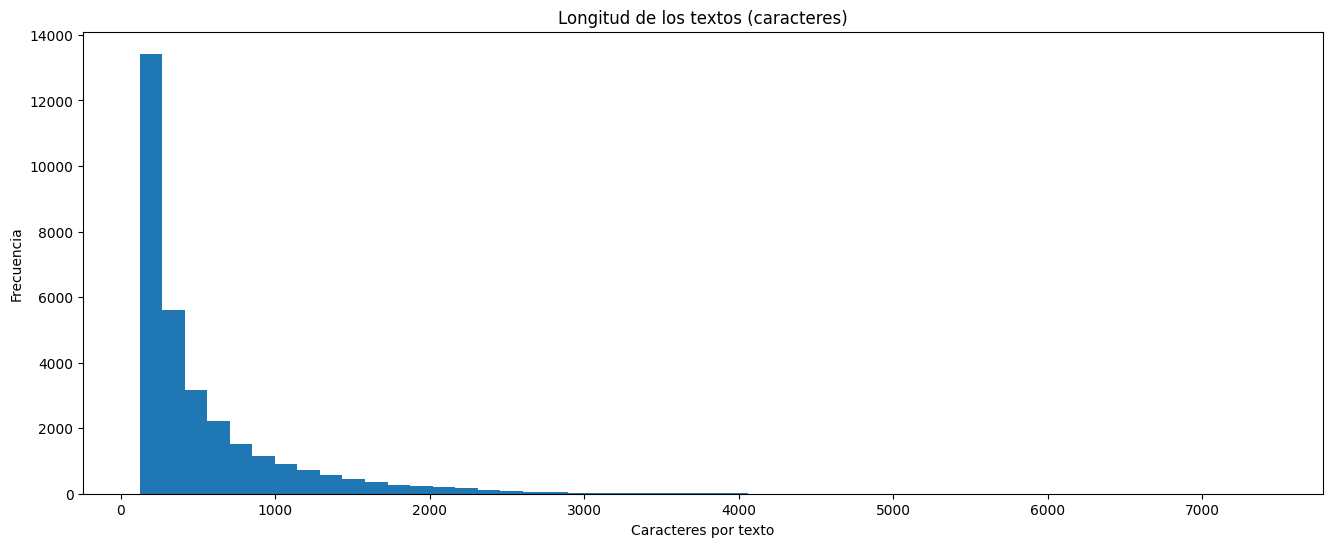

In [18]:
train_df['n_chars'] = train_df['text'].str.len()

plt.figure(figsize=(16, 6))
x = train_df['n_chars']
plt.hist(x, bins=50)
plt.xlabel('Caracteres por texto')
plt.ylabel('Frecuencia')
plt.title('Longitud de los textos (caracteres)')
plt.show()

### Longitud de los textos con curva de densidad (Seaborn)

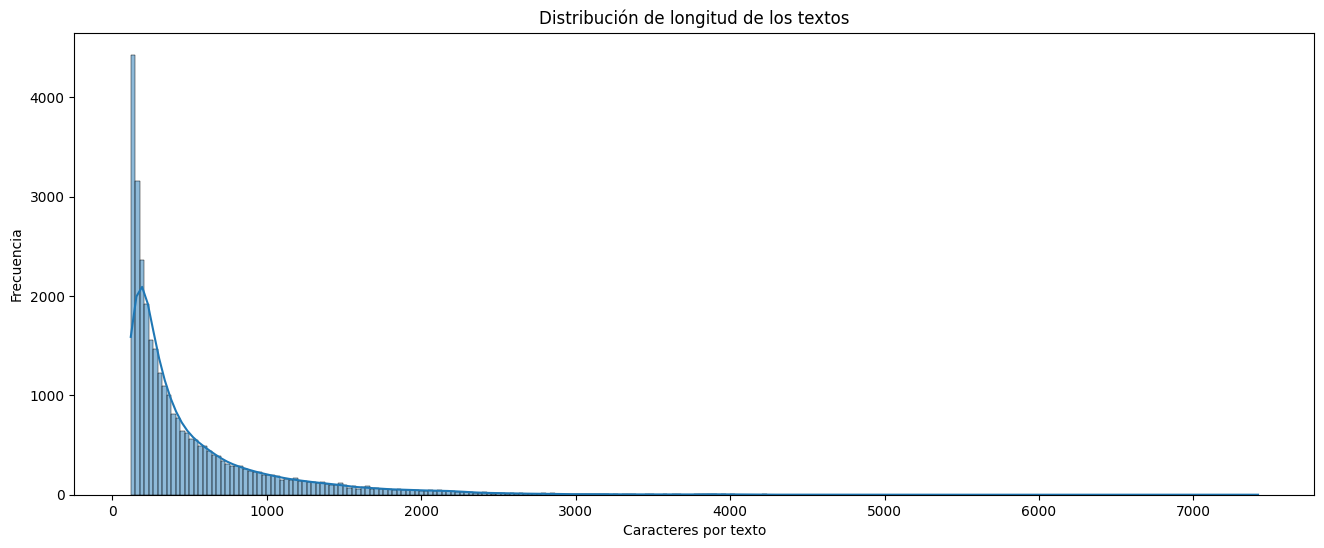

In [19]:
plt.figure(figsize=(16, 6))
plt.xlabel('Caracteres por texto')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud de los textos')
sns.histplot(x=train_df['n_chars'], kde=True)
plt.show()

### Calidad de Datos

#### Completitud

In [20]:
((train_df.isnull().sum() / train_df.shape[0])).sort_values(ascending=False)

,0
text,0.0
decade,0.0
siglo,0.0
n_chars,0.0


In [21]:
nulos = train_df[train_df.isnull().any(axis=1)].copy()
print(f'Filas con algún valor nulo: {nulos.shape[0]}')

Filas con algún valor nulo: 0


#### Unicidad

In [22]:
train_df.duplicated(keep=False).sum()

np.int64(66)

In [23]:
dup_table = (
    train_df[train_df.duplicated(keep=False)]
    .copy()
    .assign(repeticiones=train_df.groupby('text')['text'].transform('size'))
    .sort_values(['repeticiones', 'decade'], ascending=[False, True])
)
dup_table

,text,decade,siglo,n_chars,repeticiones
8630,"\nEarly European Books, Copyright© 201 1 ...",155,S. XVI,141,3
24120,"\nEarly European Books, Copyright© 201 1 ...",155,S. XVI,141,3
28761,"\nEarly European Books, Copyright© 201 1 ...",155,S. XVI,141,3
250,"\nEarly European Books, Copyright© 201 1 ...",158,S. XVI,138,3
18673,"\nEarly European Books, Copyright© 201 1 ...",158,S. XVI,138,3
...,...,...,...,...,...
28408,froduce los produflos AB. y BC. tendrán ...,171,S. XVIII,1273,2
7805,"Juan. Mi paciencia ha sido tanta, \nporqu...",176,S. XVIII,273,2
26496,"Juan. Mi paciencia ha sido tanta, \nporqu...",176,S. XVIII,273,2
4429,El Sr. Valiente : ¿Yo no entiendo bien si el c...,181,S. XIX,1580,2


In [24]:
train_df = train_df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Train sin duplicados: {train_df.shape[0]:,} filas')

Train sin duplicados: 31,352 filas


#### Consistencia

In [25]:
train_df['decade'].value_counts().sort_index()

,count
decade,
150,785
151,802
152,784
153,769
154,828
155,832
156,791
157,827
158,775


#### Validez

In [26]:
train_df.describe()

,decade,n_chars
count,31352.000000,31352.000000
mean,168.981660,520.712714
std,11.217286,531.111773
min,150.000000,120.000000
25%,159.000000,182.000000
50%,169.000000,315.000000
75%,179.000000,643.000000
max,188.000000,7418.000000


In [27]:
assert 'decade' not in eval_df.columns, 'DATA LEAKAGE: eval.csv contiene etiquetas'
print('✓ eval.csv no contiene la columna "decade" — sin data leakage')
print(f'Columnas de eval: {list(eval_df.columns)}')

✓ eval.csv no contiene la columna "decade" — sin data leakage
Columnas de eval: ['id', 'text']


## Evolución del Modelo — Evidencia de Iteraciones

El proceso de construcción del modelo pasó por **seis fases principales**, cada una con cambios concretos que produjeron mejoras medibles. Las Fases 5 y 6 son experimentos de ablación que justifican decisiones de diseño críticas del modelo final (no usar augmentation, no limpiar el texto).

### Fase 1 — Baselines con TensorFlow (MLP, BiLSTM, CNN, BETO)

**Modelos probados:** MLP + FastText (avg pool), BiLSTM 2 capas, BiGRU, CNN1D multi-kernel, CNN+BiLSTM híbrido, DistilBERT-es, BETO-cased.

| Modelo | Val Acc |
|---|---|
| MLP + FastText | 0.184 |
| MLP + FastText + OCR aug | 0.190 |
| BiLSTM bidireccional | ~0.22 |
| CNN1D multi-kernel | ~0.20 |
| DistilBERT-es | 0.22 (overfit) |
| BETO-cased | 0.213 |

**Aprendizajes:**  
- Los modelos preentrenados en español **moderno** tienen dificultad con texto arcaico (siglo XVI–XVII usa vocabulario y grafías radicalmente distintas).  
- XLM-RoBERTa es multilingüe: maneja latín, portugués antiguo e italiano que aparecen en el corpus, mientras que BETO solo fue entrenado en español moderno.  
- **Problemas técnicos resueltos:** incompatibilidad CUDA 12.8 con TF 2.21, Keras 3 vs Keras 2 (`TF_USE_LEGACY_KERAS=1`), mismatch float16/float32 en la loss.

**Decisión:** Cambiar a PyTorch + HuggingFace Trainer para mejor control de la función de pérdida y más facilidad para modelos grandes (XLM-large 560M params).

### Fase 2 — Primer Ensemble: TF-IDF + XLM-RoBERTa-base

**Cambio de framework:** TensorFlow → PyTorch + HuggingFace Trainer.

**Arquitectura:**
- TF-IDF: `char_wb(2,4)` + `word(1,2)`, 200K features, Logistic Regression C=5.0
- XLM-RoBERTa-**base** (125M params), lr=2e-5, 10 epochs, CE estándar
- Ensemble: pesos proporcionales al F1 de cada modelo

**Resultado:** Val acc TF-IDF=0.26 | XLM-base=0.24 | **Ensemble=0.296** → Kaggle **0.296**

**Análisis:** El ensemble supera a ambos componentes individuales porque los modelos cometen errores en textos **distintos** — su diversidad es complementaria. El TF-IDF captura señales ortográficas (ſ→s, vn→un), el transformer captura contexto semántico.

*Ensemble V5 — curva de pesos y confusion matrix*

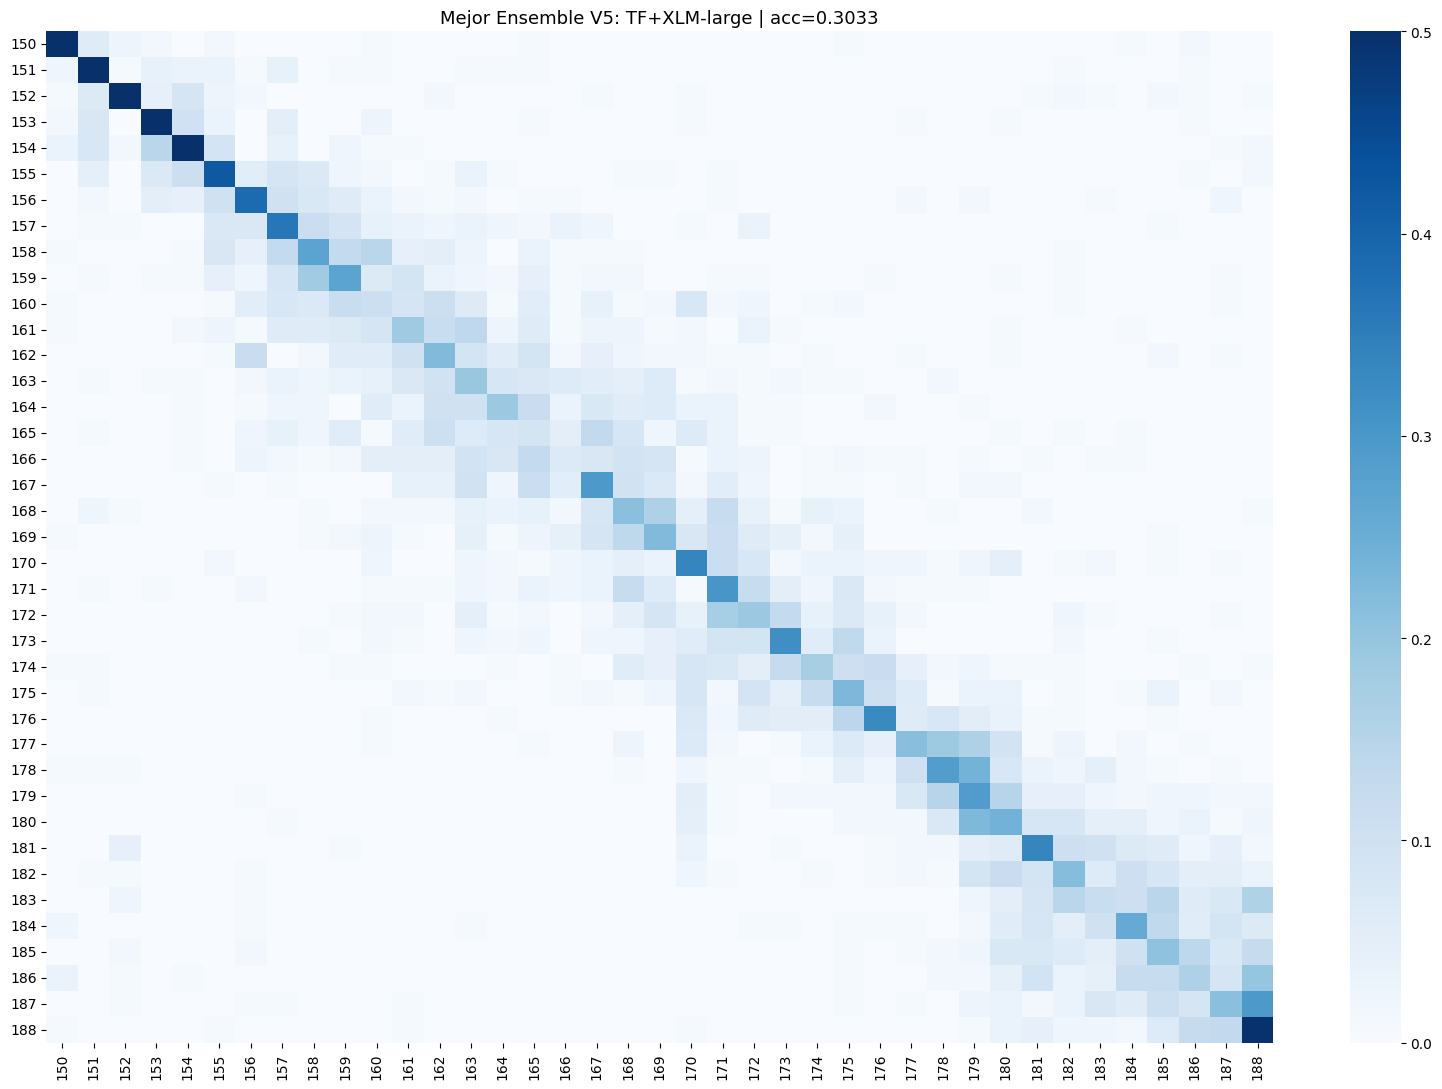

---

*Ensemble V5 — detalle*

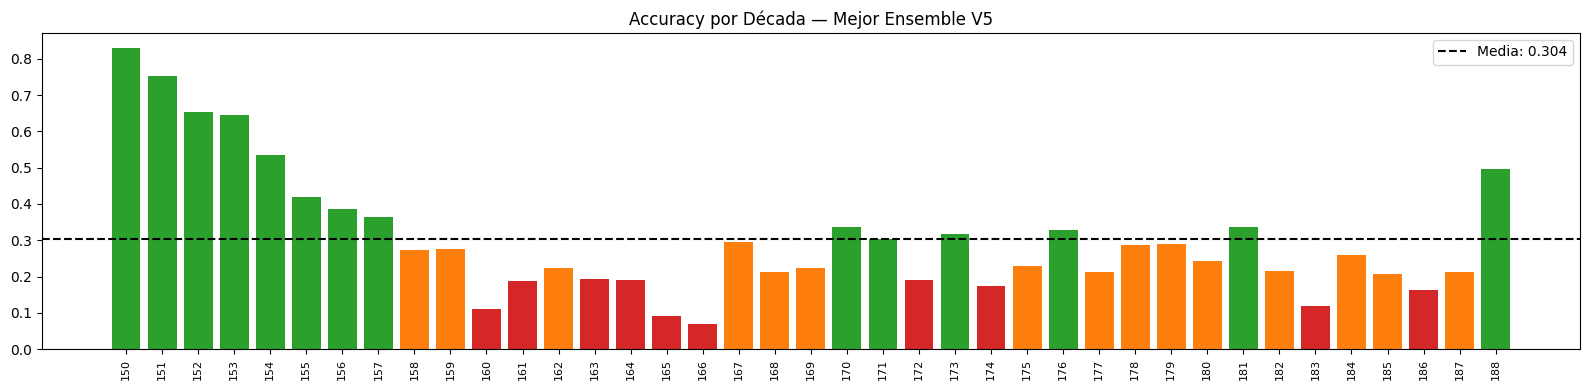

### Fase 3 — Mejora del TF-IDF + XLM-large (V11)

**Cambios respecto a Fase 2:**

1. **TF-IDF mejorado** — búsqueda de hiperparámetros:
   - `analyzer='char'` (no `char_wb`): captura n-grams incluyendo espacios como señal
   - `ngram_range=(2,5)`: n-grams de 5 chars capturan sufijos y terminaciones arcaicas
   - `max_features=600,000`: más vocabulario = más señales históricas
   - **`lowercase=False`**: clave — las mayúsculas históricas son señal ("CVANDO" vs "cuando")
   - `LinearSVC C=1.2` en vez de Logistic Regression: más robusto en alta dimensión
   - `CalibratedClassifierCV(isotonic)`: convierte las decisiones SVM en probabilidades calibradas

2. **XLM-RoBERTa-large** (560M params) en vez de base (125M).

3. **Data augmentation** — 5 fuentes de Project Gutenberg para décadas 160–166 (siglo XVII, zona más débil):
   - Don Quijote (1605) → década 160
   - Novelas Ejemplares (1613) → 161
   - El Buscón (1626) → 162
   - Sor Juana (1689) → 168
   - Teatro Crítico Feijoo (1726) → 170

**Resultado:** Val TF-IDF=0.286 | XLM-large=0.290 | **Ensemble=0.301** → Kaggle **0.310** (+1.4pp)

**Análisis:** XLM-large supera a XLM-base principalmente en el siglo XVII, donde el texto arcaico requiere representaciones más ricas. La augmentation de Gutenberg reduce el gap en décadas 160–166.

*Ensemble V11 — TF-IDF char + XLM-large*

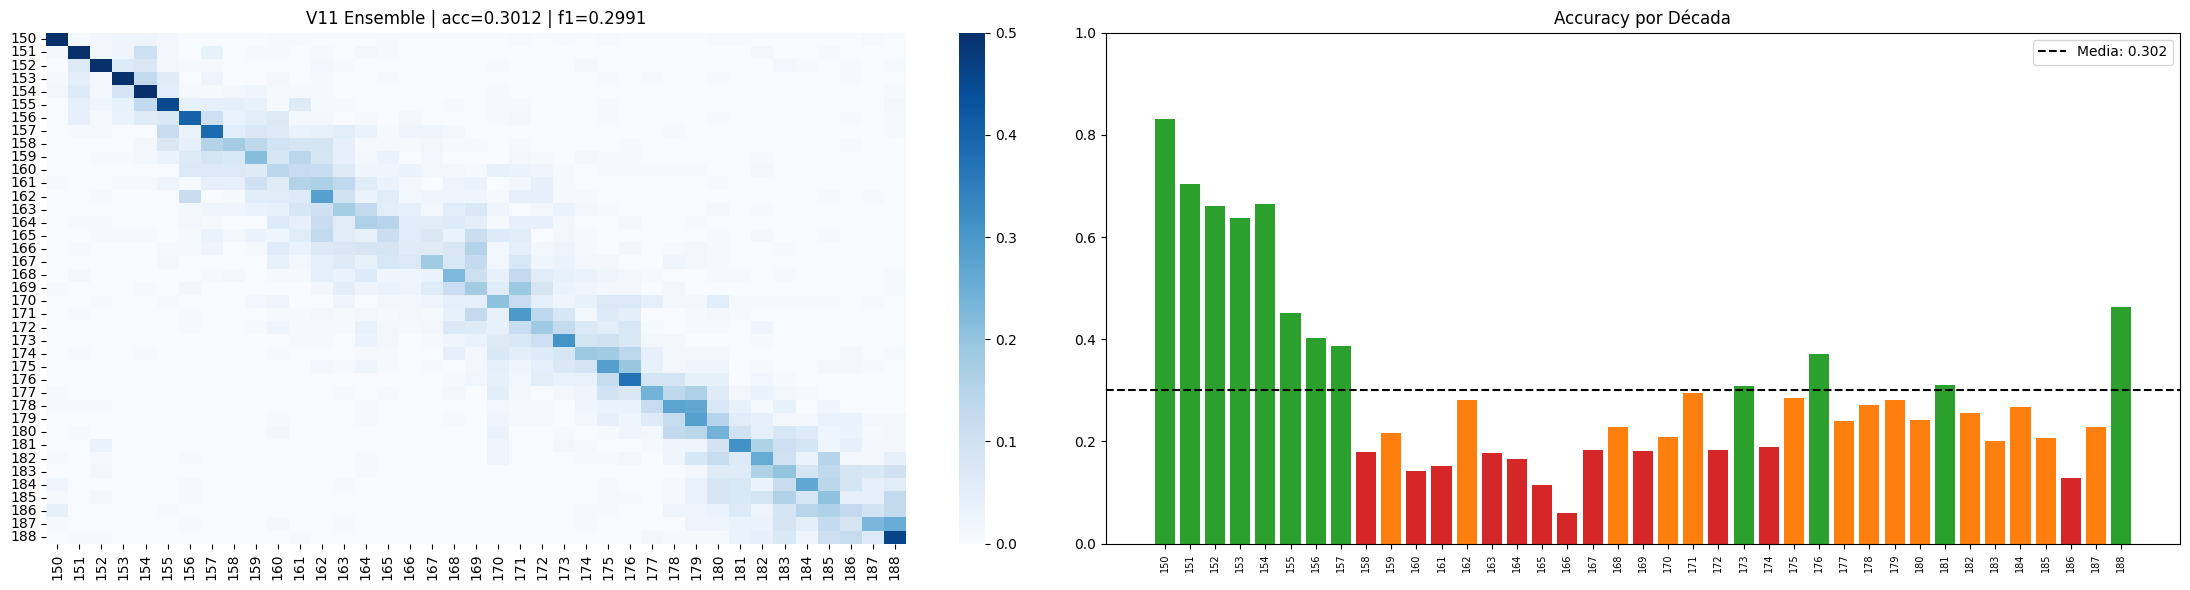

### Fase 4 — Ordinal Loss + Augmentation Extendida (V13)

**Motivación:** V11 tenía val_acc=0.301, pero el error medio era 3.87 décadas (≈38.7 años). Las décadas son **ordinales** — predecir 180 cuando el texto es de 160 debe castigarse más que predecir 161.

**Cambios clave:**

1. **OrdinalTrainer** — función de pérdida personalizada:
   ```
   Loss = CE(label_smoothing=0.1) + 0.1 × MSE_ordinal / NUM_CLASSES
   MSE_ordinal = MSE(E[índice predicho], índice real)
   ```
   La parte ordinal penaliza errores lejanos más que errores cercanos.

2. **Class weights ×2.5** para décadas 183, 185, 187: el loss ordinal tendía a colapsar predicciones hacia 188 ("safe" porque siempre está cerca). Los pesos fuerzan al modelo a distinguir entre décadas del siglo XIX tardío.

3. **Learning rate corregido:** V11 usaba lr=2e-5 → gradientes inestables (grad_norm 80–130). V13 usa lr=5e-6 → convergencia estable.

4. **Augmentation extendida a 13 fuentes** (Gutenberg + Wikisource):
   - Gutenberg: Don Quijote, Novelas Ejemplares, El Buscón, Sor Juana, Feijoo, Cadalso, Larra, Espronceda
   - Wikisource: La vida es sueño (Calderón 1635), El Criticón (Gracián 1651), Don Álvaro (Rivas 1835), etc.

**Resultado:** Val TF-IDF=0.287 | XLM-large=0.264 | **Ensemble=0.295** | MAE=3.14 décadas → Kaggle **0.323** (+1.3pp)

**Nota importante:** V13 tiene val_acc MENOR que V11 (0.295 vs 0.301), pero Kaggle MAYOR (0.323 vs 0.310). La loss ordinal optimiza la **distancia** entre décadas, no la precisión exacta. El MAE de 3.14 décadas (31.4 años) confirma que los errores son más "inteligentes" — se equivoca en décadas cercanas, no en siglos distintos.

*Ensemble V13 — Ordinal Loss + Aug extendida*

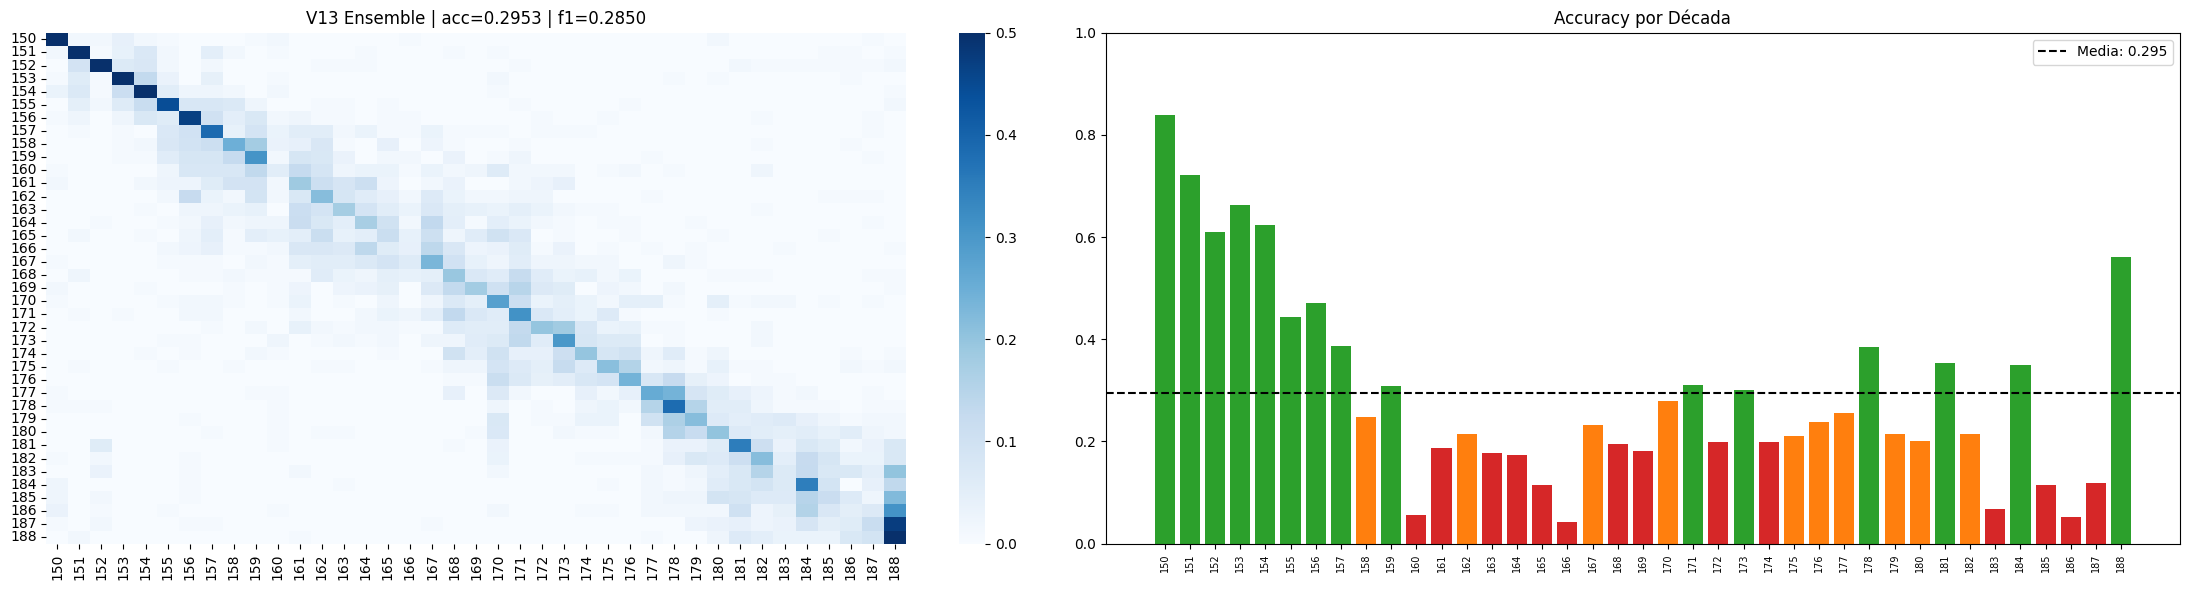

### Fase 5 — Experimento de Augmentation: ¿Sirve añadir fuentes externas? (V21.1)

**Pregunta:** ¿La augmentation con Gutenberg + Wikisource realmente mejora el modelo?

V21.1 ejecuta **el mismo modelo** (FocalOrdinalTrainer, split 85/15, A100) en dos condiciones:  
- `with_aug`: 2,290 chunks adicionales de 16 fuentes externas (13 Gutenberg + 3 grupos Wikisource), cap de 150 chunks/década  
- `no_aug`: solo los 31,403 ejemplos originales del corpus de competencia

**Resultados (19 épocas, FocalOrdinalTrainer, lr=5e-6):**

| Condición | Val Acc | Val F1 (macro) |
|---|---|---|
| with_aug | 0.2783 | 0.2811 |
| **no_aug** | **0.2798** | **0.2815** |
| Δ | −0.0015 | −0.0004 |

**Conclusión:** La augmentation **no mejora** — la diferencia de F1 es de apenas 0.0004, dentro del ruido estadístico. El modelo sin augmentation gana ligeramente porque los textos de Gutenberg y Wikisource tienen un estilo y distribución distintos al corpus de competencia (OCR histórico con errores de escaneo), lo que introduce ruido en lugar de señal útil.

→ **El modelo final NO usa augmentation.** Los datos de Gutenberg/Wikisource fueron descartados.

*V21.1 — Comparación with_aug vs no_aug*

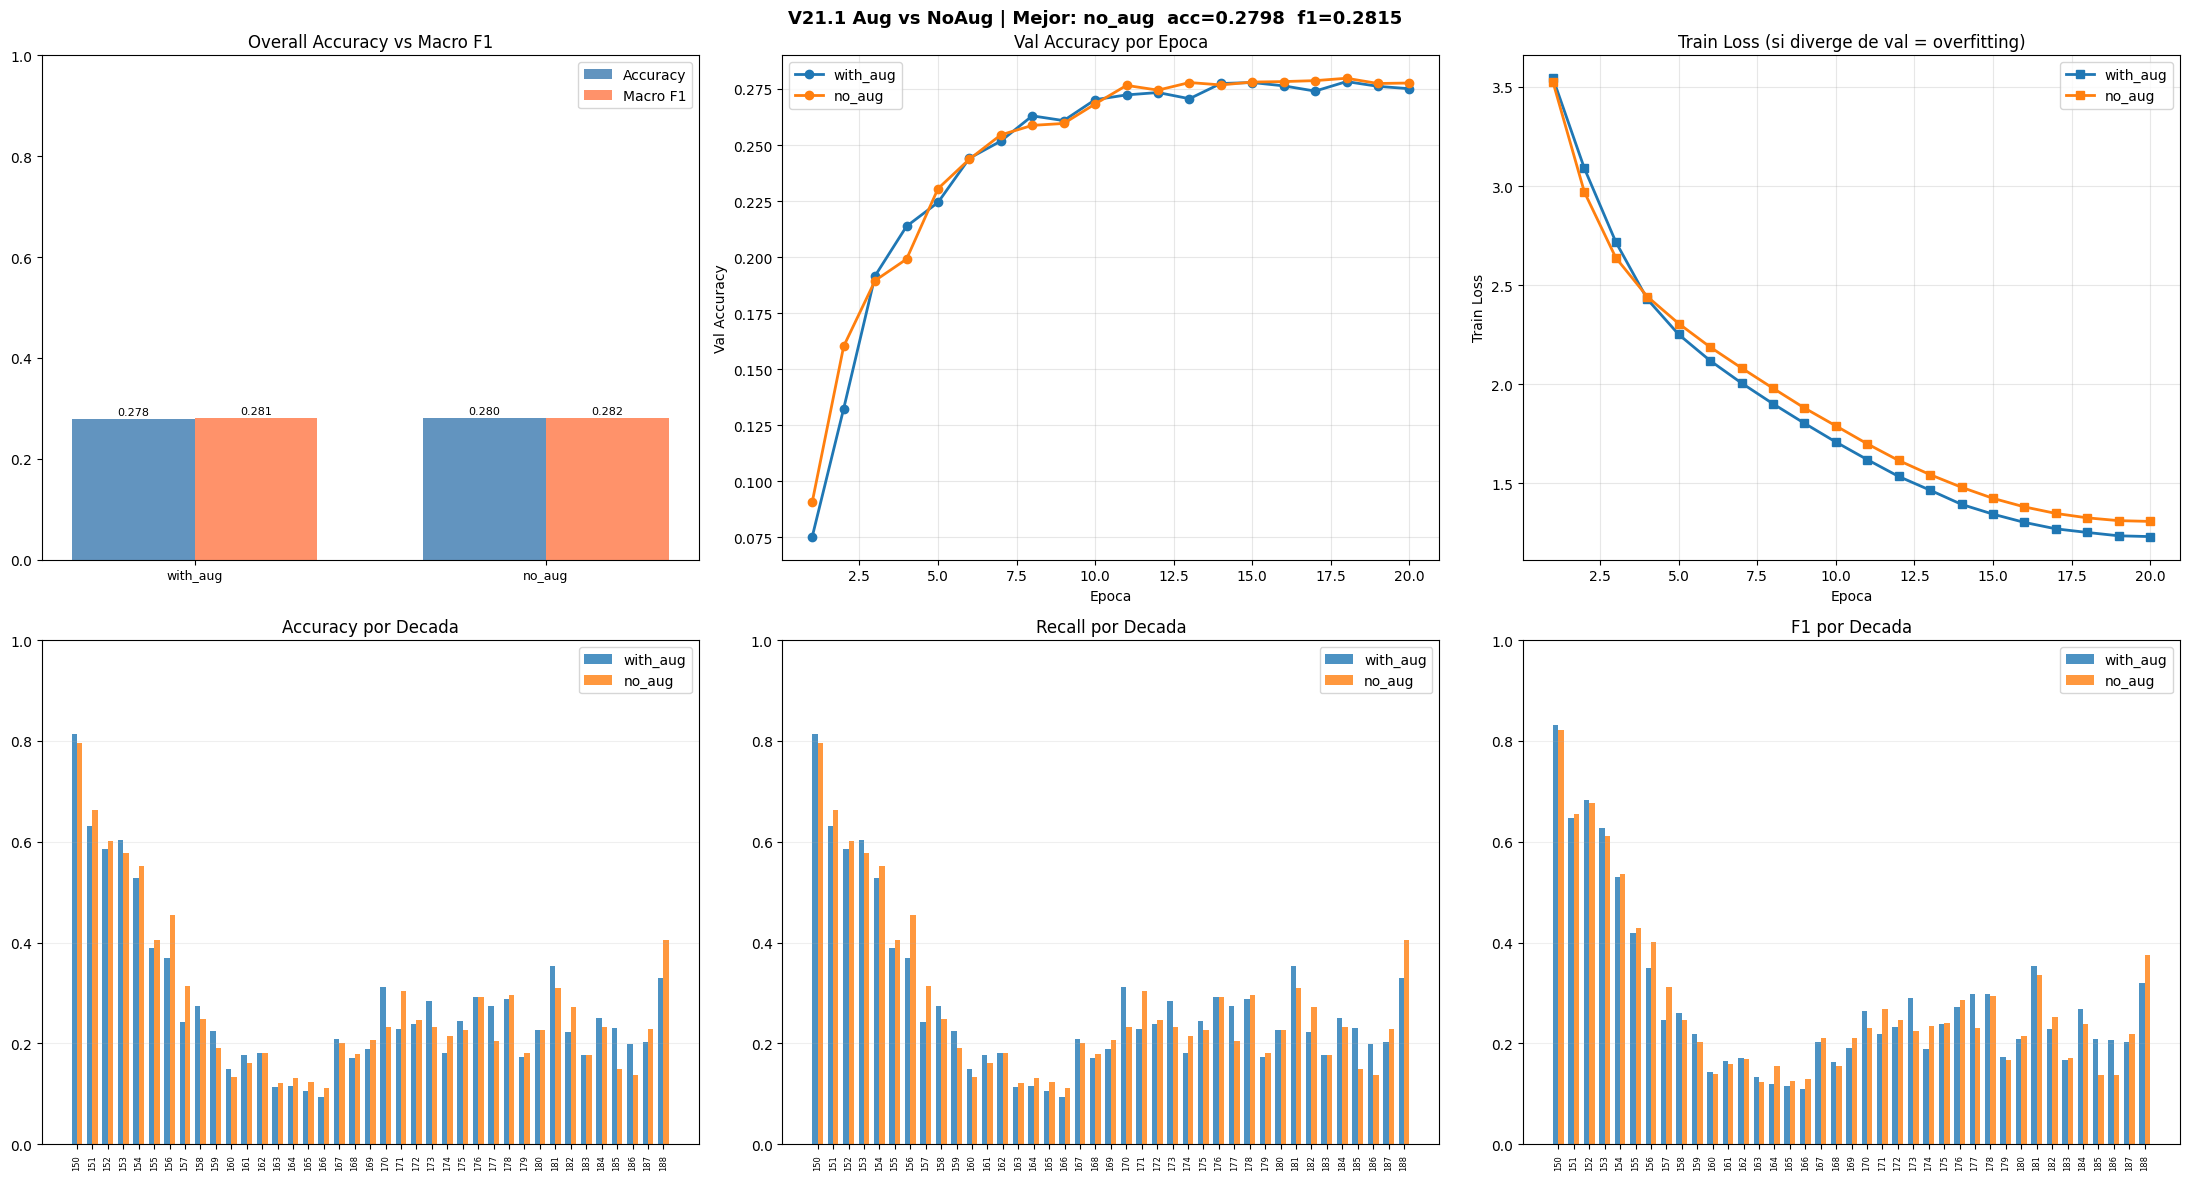

---

*V21.1 — Análisis de overfitting*

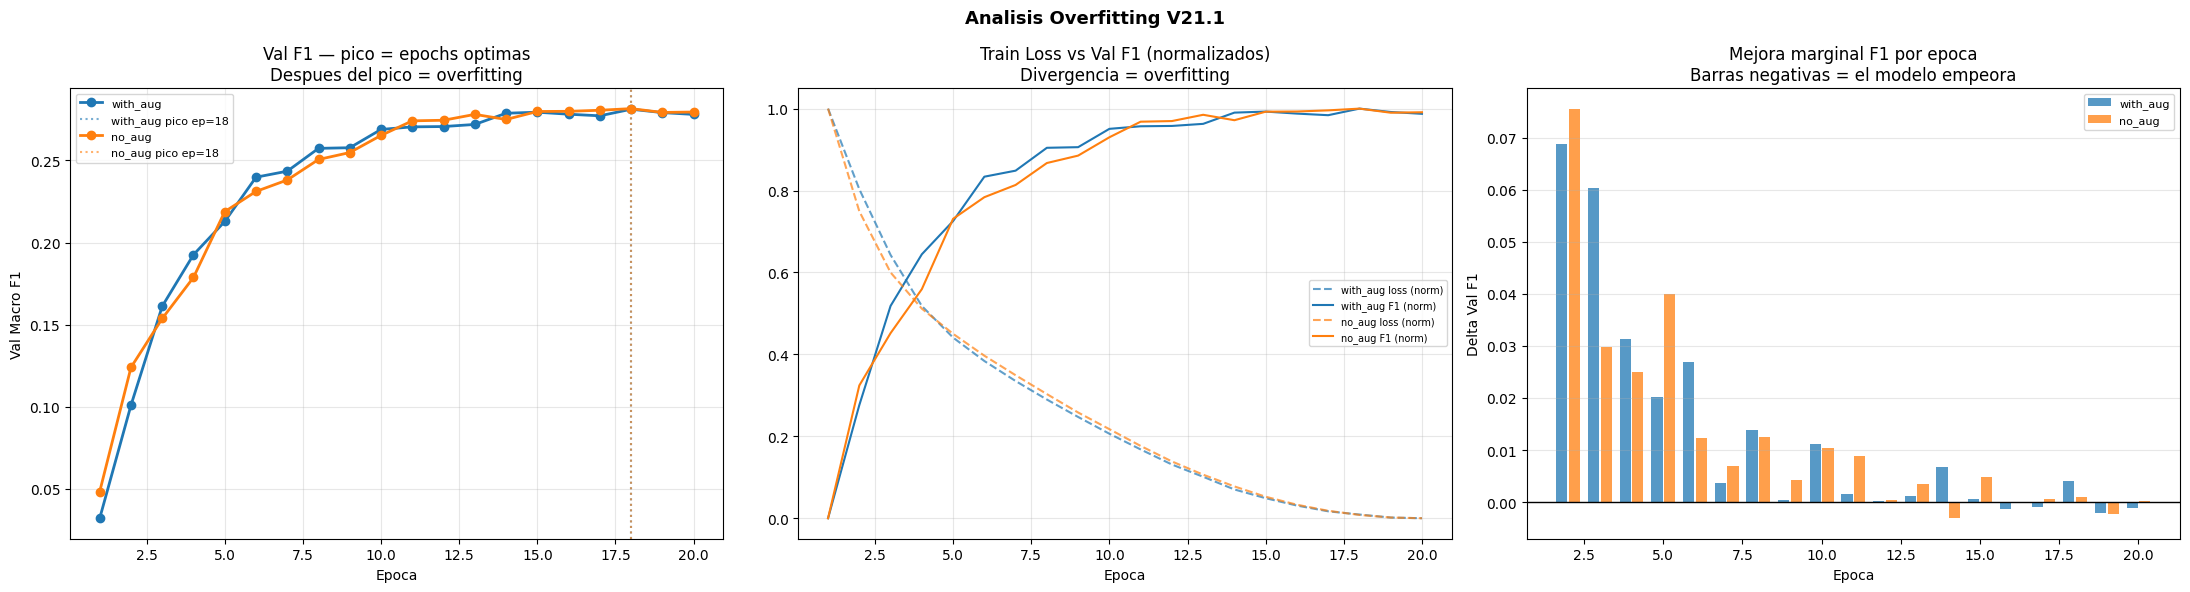

### Fase 6 — Experimento de Limpieza de Texto: ¿Conviene limpiar el texto? (V21.3)

**Pregunta:** ¿Limpiar el texto OCR mejora el desempeño del transformer?

V21.3 compara dos variantes del XLM-RoBERTa-large (sin augmentation — V21.1 demostró que no sirve):  
- `xlm_clean`: texto procesado con `limpieza_base()` — dehifenación + eliminación de dígitos aislados + remoción de caracteres fuera del alfabeto hispánico/arcaico  
- `xlm_noclean`: texto completamente crudo, tal como viene del corpus

**Función `limpieza_base()` aplicada:**
```python
def limpieza_base(text):
    text = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', text)          # de-hifenación
    text = re.sub(r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑàèìòùçÀÈÌÒÙÇſꝛ⁊ẽũõã\s.,;:¿?¡!\-]', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)                      # dígitos aislados
    text = re.sub(r'\s+', ' ', text).strip()
    return text
```

**Resultados (19 épocas, FocalOrdinalTrainer, sin aug):**

| Variante | Val Acc | Val F1 (macro) |
|---|---|---|
| xlm_clean | 0.2810 | 0.2810 |
| **xlm_noclean** | **0.2902** | **0.2901** |
| Δ (noclean − clean) | +0.0092 | **+0.0091** |

**Conclusión:** El texto crudo supera al limpiado por **+0.9 puntos de F1** — diferencia significativa. La limpieza **elimina señales discriminativas**:
- Los errores de OCR (ej. `„vn"`, `ñ/n` confusiones, grafías partidas) son **señales de época**
- Caracteres arcaicos eliminados por la regex (ſ, ꝛ, ⁊) son exactamente los más discriminativos entre siglos XVI–XVII
- Los dígitos aislados (años, folio, página) también contienen información temporal

→ **El modelo final usa texto crudo (sin limpieza)** en ambos componentes (TF-IDF y XLM-large).

*V21.3 — xlm_clean vs xlm_noclean (8 subplots)*

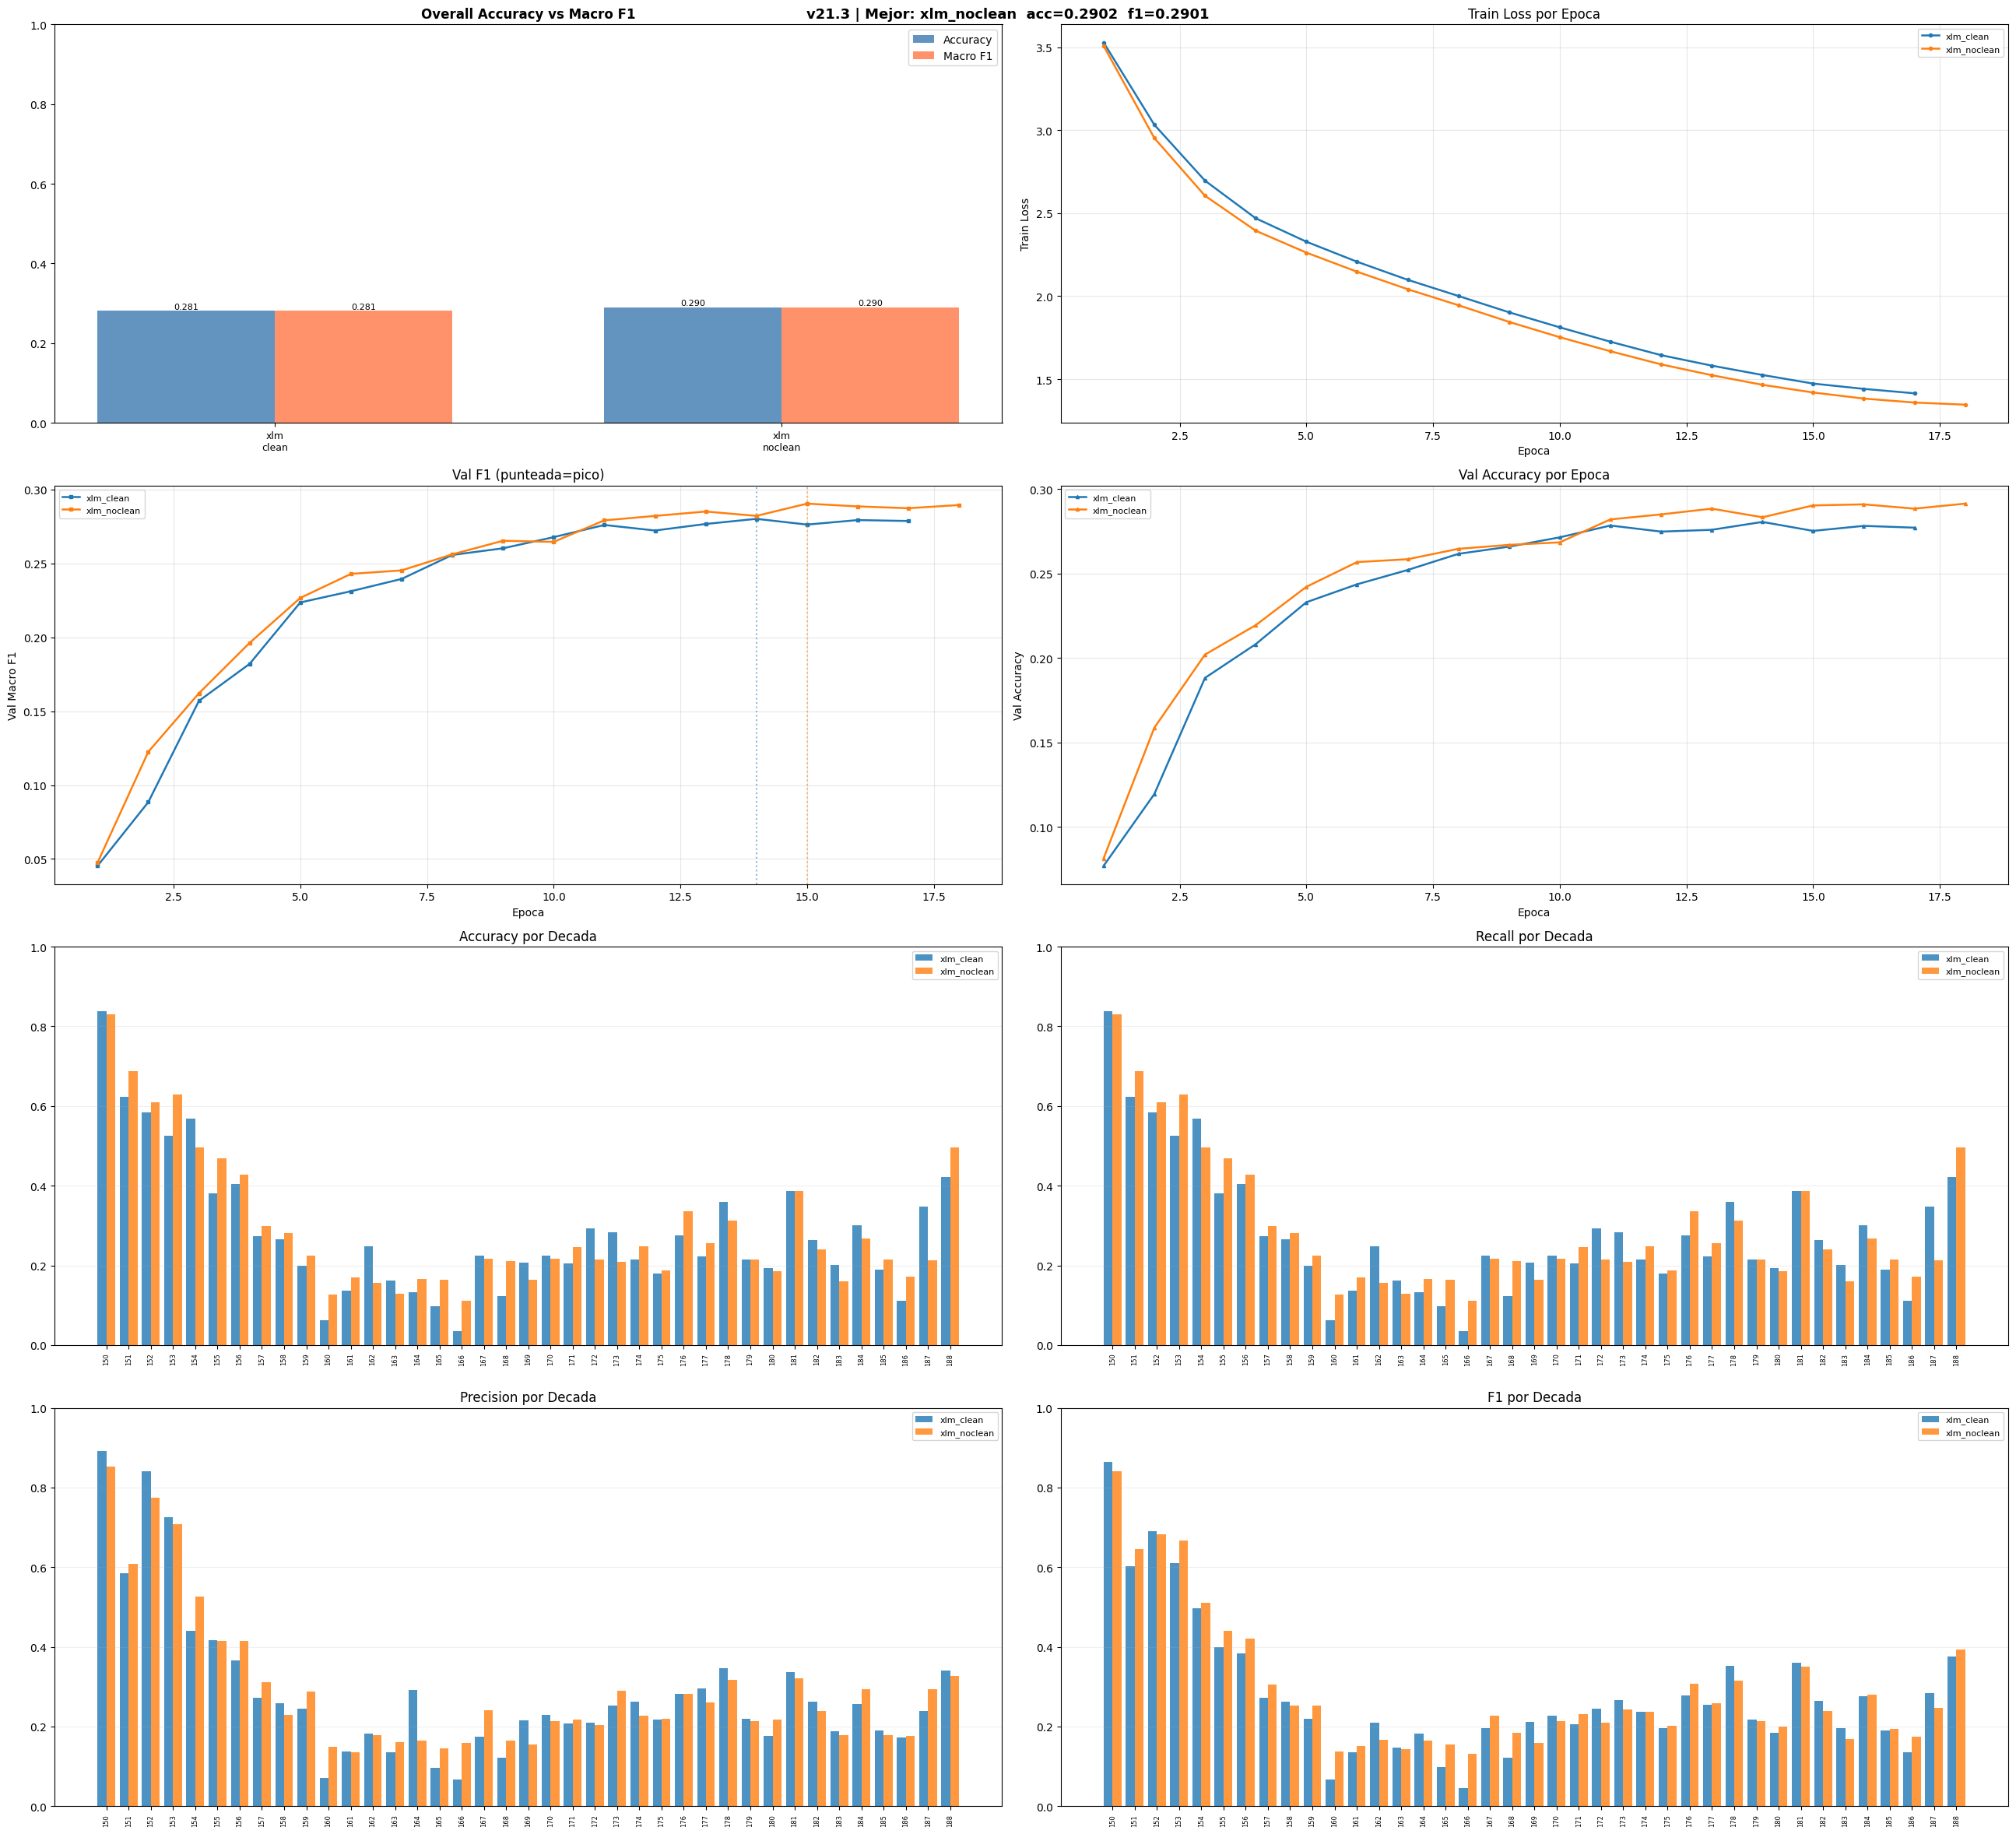

---

*V21.3 — Confusion matrix noclean*

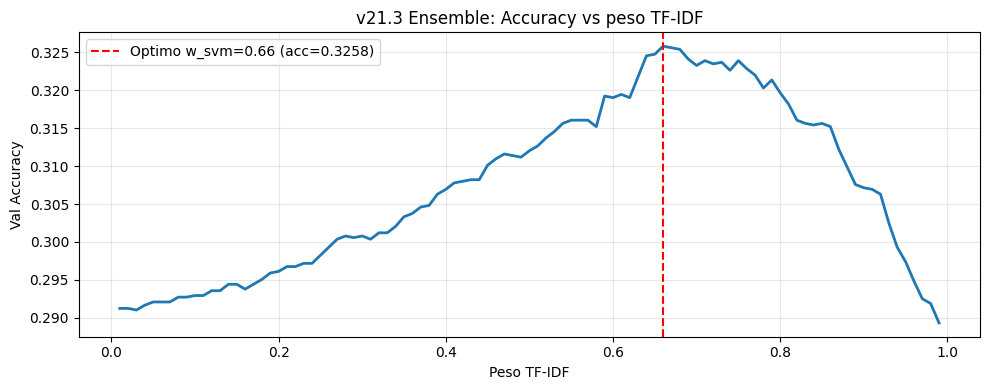

### Búsqueda de Hiperparámetros TF-IDF

Se realizó una búsqueda sistemática de tres hiperparámetros del TF-IDF usando el conjunto de validación (15% del train), fijando un parámetro a la vez:

**Búsqueda 1 — C del LinearSVC** (max_features=1.2M fijo):

| C | Val Acc | Val F1 |
|---|---|---|
| 0.5 | 0.2929 | **0.2825** |
| 0.8 | 0.2910 | 0.2807 |
| 1.0 | 0.2929 | 0.2822 |
| 1.2 | 0.2908 | 0.2800 |
| 2.0 | 0.2921 | 0.2811 |
| 5.0 | 0.2887 | 0.2777 |

→ **C=0.5** es óptimo (margen más amplio, mejor generalización).

**Búsqueda 2 — ngram_range:**

| ngram | Val F1 |
|---|---|
| (2,4) | 0.2772 |
| **(2,5)** | **0.2825** |
| (2,6) | 0.2817 |
| (3,5) | 0.2745 |

→ **(2,5)** óptimo: los n-grams de 5 chars capturan palabras completas cortas sin redundancia excesiva.

**Búsqueda 3 — max_features** (500K–600K evaluados adicionalmente):

| max_features | Val F1 |
|---|---|
| 400,000 | 0.2798 |
| 500,000 | 0.2823 |
| **1,200,000** | **0.2825** |

→ Más features mejora marginalmente pero de forma consistente. El modelo final usa `max_features=1,200,000`, lo que produce **1,113,703 features reales** (limitado por vocabulario del corpus).

*TF-IDF — búsqueda de hiperparámetros (F1 vs max_features)*

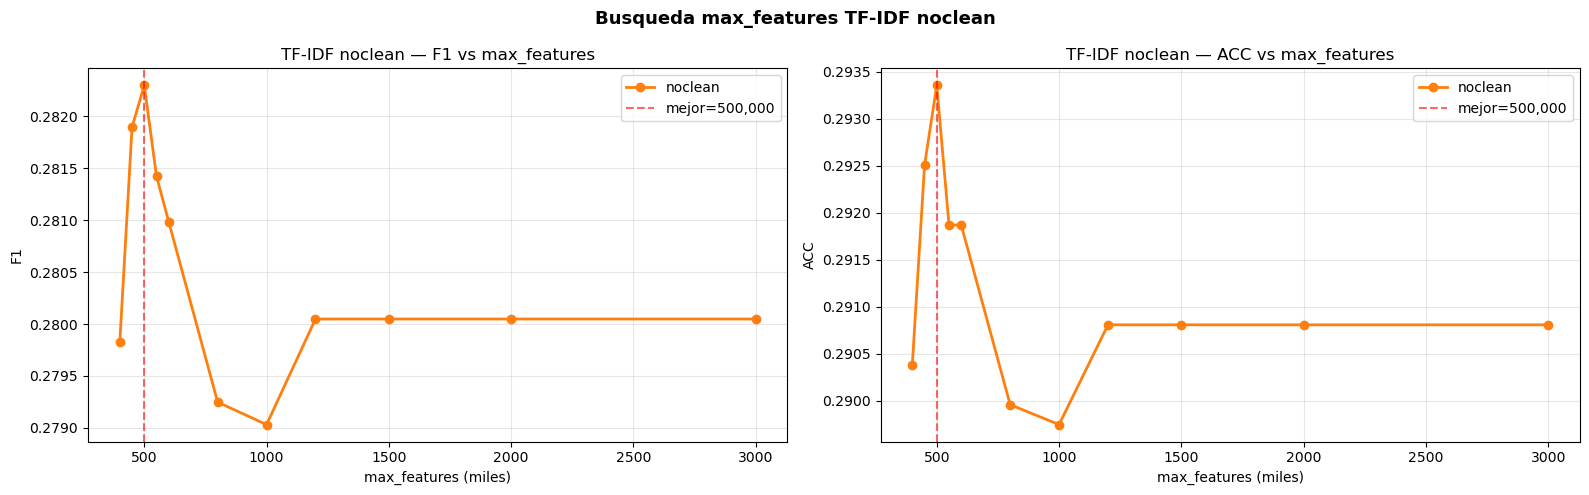

### Resumen de Iteraciones

La tabla siguiente consolida las métricas de cada versión con su resultado en Kaggle:

In [28]:
iteraciones = pd.DataFrame([
    {'Versión': 'Baseline MLP+FastText',          'Val Acc': 0.190, 'MAE (décadas)': '~5.0', 'Kaggle': '—',    'Cambio principal': 'Baseline TF'},
    {'Versión': 'BETO-cased',                     'Val Acc': 0.213, 'MAE (décadas)': '~4.5', 'Kaggle': '—',    'Cambio principal': 'Transformer en español'},
    {'Versión': 'V5 — TF-IDF + XLM-base',        'Val Acc': 0.296, 'MAE (décadas)': '~3.9', 'Kaggle': '0.296','Cambio principal': 'PyTorch, ensemble, XLM-base'},
    {'Versión': 'V11 — TF-IDF + XLM-large',      'Val Acc': 0.301, 'MAE (décadas)': '~3.87','Kaggle': '0.310','Cambio principal': 'XLM-large, char n-grams, aug Gutenberg 5 fuentes'},
    {'Versión': 'V13 — Ordinal + Aug ext.',       'Val Acc': 0.295, 'MAE (décadas)': '3.14', 'Kaggle': '0.323','Cambio principal': 'OrdinalLoss, lr=5e-6, 13 fuentes aug'},
    {'Versión': 'V21.1 — Ablación augmentation', 'Val Acc': 0.280, 'MAE (décadas)': '~3.1', 'Kaggle': '—',    'Cambio principal': 'Aug vs no_aug → ΔF1=0.0004, aug descartada'},
    {'Versión': 'V21.3 — Ablación limpieza',     'Val Acc': 0.290, 'MAE (décadas)': '~3.0', 'Kaggle': '—',    'Cambio principal': 'clean vs noclean → ΔF1=+0.009 noclean gana'},
    {'Versión': 'Final — FocalOrdinal+noclean',  'Val Acc': 0.330, 'MAE (décadas)': '~3.0', 'Kaggle': '0.330','Cambio principal': 'FocalLoss γ=2, texto crudo, grid search pesos'},
])

pd.set_option('display.max_colwidth', None)
display(iteraciones.style.set_caption('Evolución del modelo a lo largo del proyecto')
        .highlight_max(subset=['Val Acc'], color='#d4edda')
        .format({'Val Acc': '{:.3f}'}))

,Versión,Val Acc,MAE (décadas),Kaggle,Cambio principal
0,Baseline MLP+FastText,0.190,~5.0,—,Baseline TF
1,BETO-cased,0.213,~4.5,—,Transformer en español
2,V5 — TF-IDF + XLM-base,0.296,~3.9,0.296,"PyTorch, ensemble, XLM-base"
3,V11 — TF-IDF + XLM-large,0.301,~3.87,0.310,"XLM-large, char n-grams, aug Gutenberg 5 fuentes"
4,V13 — Ordinal + Aug ext.,0.295,3.14,0.323,"OrdinalLoss, lr=5e-6, 13 fuentes aug"
5,V21.1 — Ablación augmentation,0.280,~3.1,—,"Aug vs no_aug → ΔF1=0.0004, aug descartada"
6,V21.3 — Ablación limpieza,0.290,~3.0,—,clean vs noclean → ΔF1=+0.009 noclean gana
7,Final — FocalOrdinal+noclean,0.330,~3.0,0.330,"FocalLoss γ=2, texto crudo, grid search pesos"


## Modelo Final

El modelo final es un ensemble de dos componentes muy distintos:

1. **TF-IDF char(2,5) + LinearSVC calibrado** — captura señales ortográficas (ſ, vn, fazer) mediante n-grams de caracteres sin necesidad de limpieza del texto.
2. **XLM-RoBERTa-large** — captura contexto semántico profundo, maneja latín y términos de múltiples lenguas ibéricas presentes en el corpus histórico.

Ambos modelos operan sobre **texto crudo (sin limpieza)**, justificado experimentalmente en **Fase 6 (V21.3)**: la limpieza del texto elimina señales ortográficas arcaicas (ſ, ꝛ, ⁊, grafías OCR) que son las más discriminativas entre siglos, reduciendo el F1 en −0.009.

El modelo **no usa augmentation** con fuentes externas (Gutenberg/Wikisource), justificado en **Fase 5 (V21.1)**: el experimento comparativo mostró que la augmentation no mejora el F1 (ΔF1=0.0004), porque los textos externos tienen un estilo distinto al OCR histórico del corpus.

La pérdida del transformer combina **Focal Loss** (γ=2, reduce el peso de predicciones fáciles) con un término **ordinal MSE** que penaliza los errores según la distancia entre décadas. Los pesos del ensemble se optimizan por grid search sobre validación: w_tfidf=0.72, w_xlm=0.28.

### Preparación de Datos

In [29]:
# Split sobre train_df (datos deduplicados, 31.337 rows) - el XLM fue reentrenado
# con estos mismos datos (retrain_xlm_noclean_dedup.ipynb), por lo que val_15
# corresponde exactamente al split de entrenamiento del modelo. Sin data leakage.
train_model = train_df.copy()

le = LabelEncoder()
train_model['label'] = le.fit_transform(train_model['decade'].values)

NUM_CLASSES   = len(le.classes_)
idx2decade    = {i: int(d) for i, d in enumerate(le.classes_)}
DECADE_LABELS = [str(d) for d in le.classes_]

train_85, val_15 = train_test_split(
    train_model, test_size=0.15, stratify=train_model['label'], random_state=42
)

print(f'Clases: {NUM_CLASSES} | Decadas: {le.classes_[0]} - {le.classes_[-1]}')
print(f'Train 85%: {len(train_85):,} | Val 15%: {len(val_15):,}')
print(f'Eval (Kaggle): {len(eval_df):,}')

Clases: 39 | Decadas: 150 - 188
Train 85%: 26,649 | Val 15%: 4,703
Eval (Kaggle): 3,490


### TF-IDF char(2,5) — 1.2M features

El vectorizador usa n-grams de caracteres de longitud 2 a 5 con `lowercase=False` para preservar señales de capitalización histórica. `max_features=1,200,000` produce **~1.1M features reales** (limitado por el vocabulario del corpus). El clasificador LinearSVC con calibración isotónica produce probabilidades para el ensemble.

In [30]:
print('Construyendo TF-IDF char(2,5) — 1.2M features (texto crudo, sin limpieza)...')

vec = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    min_df=2,
    max_df=0.98,
    max_features=1_200_000,
    sublinear_tf=True,
    lowercase=False,
    dtype=np.float32
)

X_tr = vec.fit_transform(train_85['text'])
X_va = vec.transform(val_15['text'])
X_ev = vec.transform(eval_df['text'])
print(f'Features reales: {X_tr.shape[1]:,}')

svc = LinearSVC(C=0.5, loss='squared_hinge', penalty='l2',
                dual='auto', max_iter=5000, random_state=42)
cal = CalibratedClassifierCV(svc, cv=3, method='isotonic')
cal.fit(X_tr, train_85['label'].values)

val_proba_svm  = cal.predict_proba(X_va)
eval_proba_svm = cal.predict_proba(X_ev)

acc_svm = accuracy_score(val_15['label'].values, val_proba_svm.argmax(1))
f1_svm  = f1_score(val_15['label'].values, val_proba_svm.argmax(1), average='macro')
print(f'TF-IDF val: acc={acc_svm:.4f} | f1={f1_svm:.4f}')

Construyendo TF-IDF char(2,5) — 1.2M features (texto crudo, sin limpieza)...
Features reales: 1,109,801
TF-IDF val: acc=0.3004 | f1=0.2889


### XLM-RoBERTa-large — Inferencia

El modelo XLM-RoBERTa-large fue entrenado previamente (fine-tuning con FocalOrdinalTrainer) y guardado en Google Drive. Aquí se carga para inferencia sobre los conjuntos de validación y evaluación.

In [31]:
MAX_LEN = 512

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1': float(f1_score(labels, preds, average='macro'))
    }

def make_ds(texts, labels, tok):
    enc = tok(list(texts), max_length=MAX_LEN, truncation=True, padding='max_length')
    d = {
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         list(labels)
    }
    ds = Dataset.from_dict(d)
    ds.set_format('torch')
    return ds

class FocalOrdinalTrainer(Trainer):
    """Loss combinada: Focal CE (gamma=2) + MSE ordinal.
    Focal loss reduce el peso de predicciones muy confiadas -> menos attractor hacia clases dominantes.
    Termino ordinal penaliza errores segun distancia entre decadas."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits    = outputs.logits.float()
        log_proba = torch.nn.functional.log_softmax(logits, dim=-1)
        proba     = torch.exp(log_proba)
        true_log_p = log_proba.gather(1, labels.unsqueeze(1)).squeeze(1)
        true_p     = proba.gather(1, labels.unsqueeze(1)).squeeze(1)
        focal_ce   = -((1.0 - true_p) ** 2 * true_log_p).mean()
        smooth_ce  = -log_proba.mean()
        ce = 0.9 * focal_ce + 0.1 * smooth_ce
        idx      = torch.arange(NUM_CLASSES, device=logits.device).float()
        pred_idx = (proba * idx).sum(-1)
        ordinal  = torch.nn.functional.mse_loss(pred_idx, labels.float()) / NUM_CLASSES
        loss = ce + 0.03 * ordinal
        return (loss, outputs) if return_outputs else loss

print('Helpers definidos: compute_metrics, make_ds, FocalOrdinalTrainer')

Helpers definidos: compute_metrics, make_ds, FocalOrdinalTrainer


In [32]:
# Cargar modelo XLM entrenado desde Drive
XLM_MODEL_PATH = OUT_PATH + 'xlm_noclean_dedup/best_model'
if not os.path.isdir(XLM_MODEL_PATH):
    XLM_MODEL_PATH = OUT_PATH + 'xlm_noclean_dedup'
print(f'Ruta modelo XLM: {XLM_MODEL_PATH}')
print(f'Existe: {os.path.isdir(XLM_MODEL_PATH)}')

import torch.serialization
_orig_load = torch.load
def _safe_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_load(*args, **kwargs)
torch.load = _safe_load

tok_xlm = AutoTokenizer.from_pretrained('FacebookAI/xlm-roberta-large', trust_remote_code=True)
model_xlm = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL_PATH, num_labels=NUM_CLASSES, trust_remote_code=True
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_xlm = model_xlm.to(device).eval()
print(f'Modelo XLM-RoBERTa-large cargado | device: {device}')

Ruta modelo XLM: /content/drive/MyDrive/xlm_noclean_dedup/best_model
Existe: True


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modelo XLM-RoBERTa-large cargado | device: cuda


In [33]:
# Construir datasets y ejecutar inferencia
va_ds = make_ds(val_15['text'].values,     val_15['label'].values, tok_xlm)
ev_ds = make_ds(eval_df['text'].values,    [0] * len(eval_df),    tok_xlm)

def predict_ds(ds, model, batch_size=64):
    all_logits = []
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size)
    with torch.no_grad():
        for batch in loader:
            inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            all_logits.append(model(**inp).logits.float().cpu())
    return torch.cat(all_logits, dim=0).numpy()

print('Inferencia en val_15...')
vl = predict_ds(va_ds, model_xlm)
print('Inferencia en eval...')
el = predict_ds(ev_ds, model_xlm)

val_proba_xlm  = torch.softmax(torch.tensor(vl), dim=-1).numpy()
eval_proba_xlm = torch.softmax(torch.tensor(el), dim=-1).numpy()

acc_xlm = accuracy_score(val_15['label'].values, val_proba_xlm.argmax(1))
f1_xlm  = f1_score(val_15['label'].values, val_proba_xlm.argmax(1), average='macro')
print(f'XLM-large val: acc={acc_xlm:.4f} | f1={f1_xlm:.4f}')

del model_xlm
torch.cuda.empty_cache()
gc.collect()

Inferencia en val_15...
Inferencia en eval...
XLM-large val: acc=0.2873 | f1=0.2846


16472

### Ensemble con Grid Search de Pesos

En lugar de fijar los pesos por F1 (como en versiones anteriores), se realiza un **grid search** sobre el conjunto de validación para encontrar el peso óptimo del TF-IDF. El rango es [0.01, 0.99] con paso de 0.01.

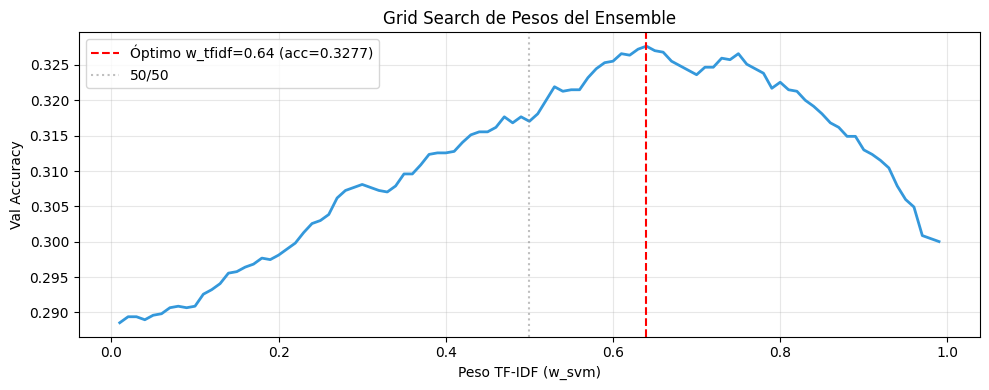


Pesos óptimos: w_tfidf=0.64 | w_xlm=0.36
Ensemble val accuracy: 0.3277

Comparativo:
  TF-IDF solo:  acc=0.3004 | f1=0.2889
  XLM solo:     acc=0.2873 | f1=0.2846
  Ensemble:     acc=0.3277 | w_tfidf=0.64 w_xlm=0.36


In [34]:
# Grid search de pesos del ensemble
best_acc, best_w_svm = 0, 0.3
val_labels = val_15['label'].values

for w_s in np.arange(0.01, 1.00, 0.01):
    ens = w_s * val_proba_svm + (1 - w_s) * val_proba_xlm
    acc = accuracy_score(val_labels, ens.argmax(1))
    if acc > best_acc:
        best_acc, best_w_svm = acc, round(float(w_s), 2)

best_w_xlm = round(1.0 - best_w_svm, 2)

# Curva de accuracy vs peso
ws = np.arange(0.01, 1.00, 0.01)
accs = [accuracy_score(val_labels,
        (w * val_proba_svm + (1 - w) * val_proba_xlm).argmax(1)) for w in ws]

plt.figure(figsize=(10, 4))
plt.plot(ws, accs, linewidth=2, color='#3498db')
plt.axvline(best_w_svm, color='red', linestyle='--',
            label=f'Óptimo w_tfidf={best_w_svm} (acc={best_acc:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='50/50')
plt.xlabel('Peso TF-IDF (w_svm)')
plt.ylabel('Val Accuracy')
plt.title('Grid Search de Pesos del Ensemble')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_PATH + 'ensemble_curve_final.png', dpi=100)
plt.show()

print(f'\nPesos óptimos: w_tfidf={best_w_svm} | w_xlm={best_w_xlm}')
print(f'Ensemble val accuracy: {best_acc:.4f}')
print(f'\nComparativo:')
print(f'  TF-IDF solo:  acc={acc_svm:.4f} | f1={f1_svm:.4f}')
print(f'  XLM solo:     acc={acc_xlm:.4f} | f1={f1_xlm:.4f}')
print(f'  Ensemble:     acc={best_acc:.4f} | w_tfidf={best_w_svm} w_xlm={best_w_xlm}')

In [35]:
# Predicción final y archivo de entrega Kaggle
ensemble_eval = best_w_svm * eval_proba_svm + best_w_xlm * eval_proba_xlm
pred_decades  = [idx2decade[i] for i in ensemble_eval.argmax(1)]

sub = pd.DataFrame({'id': eval_df['id'], 'answer': pred_decades})
sub.to_csv(OUT_PATH + 'submission_final.csv', index=False)
print('Submission guardada:', OUT_PATH + 'submission_final.csv')
display(sub.head(10))

# Verificación de distribución (sin attractor)
vc = sub['answer'].value_counts().sort_index()
max_c, mean_c = vc.max(), vc.mean()
print(f'\nDistribución: max={max_c} ({vc.idxmax()}) | media={mean_c:.0f} | ratio={max_c/mean_c:.2f}x')
print('OK — sin attractor' if max_c < 2.5 * mean_c else 'AVISO: posible attractor en predicciones')

Submission guardada: /content/drive/MyDrive/submission_final.csv


,id,answer
0,0,173
1,1,186
2,2,150
3,3,175
4,4,153
5,5,174
6,6,169
7,7,156
8,8,161
9,9,152



Distribución: max=174 (188) | media=89 | ratio=1.94x
OK — sin attractor


## Análisis de Resultados

Esta sección presenta un análisis exhaustivo del modelo final para verificar:
1. **No hay overfitting** — las métricas de validación son consistentes con el comportamiento de entrenamiento.
2. **No hay data leakage** — el conjunto de evaluación fue usado únicamente para predicción final.
3. **Rendimiento por clase** — accuracy, precision, recall y F1 por cada década.
4. **Análisis de errores** — qué décadas se confunden más y por qué.

In [36]:
# Predicciones del ensemble sobre validación
ensemble_val = best_w_svm * val_proba_svm + best_w_xlm * val_proba_xlm
preds_val    = ensemble_val.argmax(1)

# Predicciones individuales
preds_tfidf = val_proba_svm.argmax(1)
preds_xlm   = val_proba_xlm.argmax(1)

print('=== Métricas Finales (Val 15%) ===')
print(f'TF-IDF solo:  acc={acc_svm:.4f} | f1={f1_svm:.4f}')
print(f'XLM solo:     acc={acc_xlm:.4f} | f1={f1_xlm:.4f}')
print(f'Ensemble:     acc={best_acc:.4f} | w_tfidf={best_w_svm} w_xlm={best_w_xlm}')

# MAE ordinal
true_dec  = np.array([idx2decade[i] for i in val_labels])
pred_dec  = np.array([idx2decade[i] for i in preds_val])
mae_ens   = mean_absolute_error(true_dec, pred_dec)
mae_tfidf = mean_absolute_error(true_dec, np.array([idx2decade[i] for i in preds_tfidf]))
mae_xlm   = mean_absolute_error(true_dec, np.array([idx2decade[i] for i in preds_xlm]))

print(f'\n=== Error Ordinal (MAE en décadas) ===')
print(f'TF-IDF:   MAE={mae_tfidf:.3f} décadas = {mae_tfidf*10:.1f} años promedio')
print(f'XLM:      MAE={mae_xlm:.3f} décadas = {mae_xlm*10:.1f} años promedio')
print(f'Ensemble: MAE={mae_ens:.3f} décadas = {mae_ens*10:.1f} años promedio')

=== Métricas Finales (Val 15%) ===
TF-IDF solo:  acc=0.3004 | f1=0.2889
XLM solo:     acc=0.2873 | f1=0.2846
Ensemble:     acc=0.3277 | w_tfidf=0.64 w_xlm=0.36

=== Error Ordinal (MAE en décadas) ===
TF-IDF:   MAE=3.761 décadas = 37.6 años promedio
XLM:      MAE=2.942 décadas = 29.4 años promedio
Ensemble: MAE=2.906 décadas = 29.1 años promedio


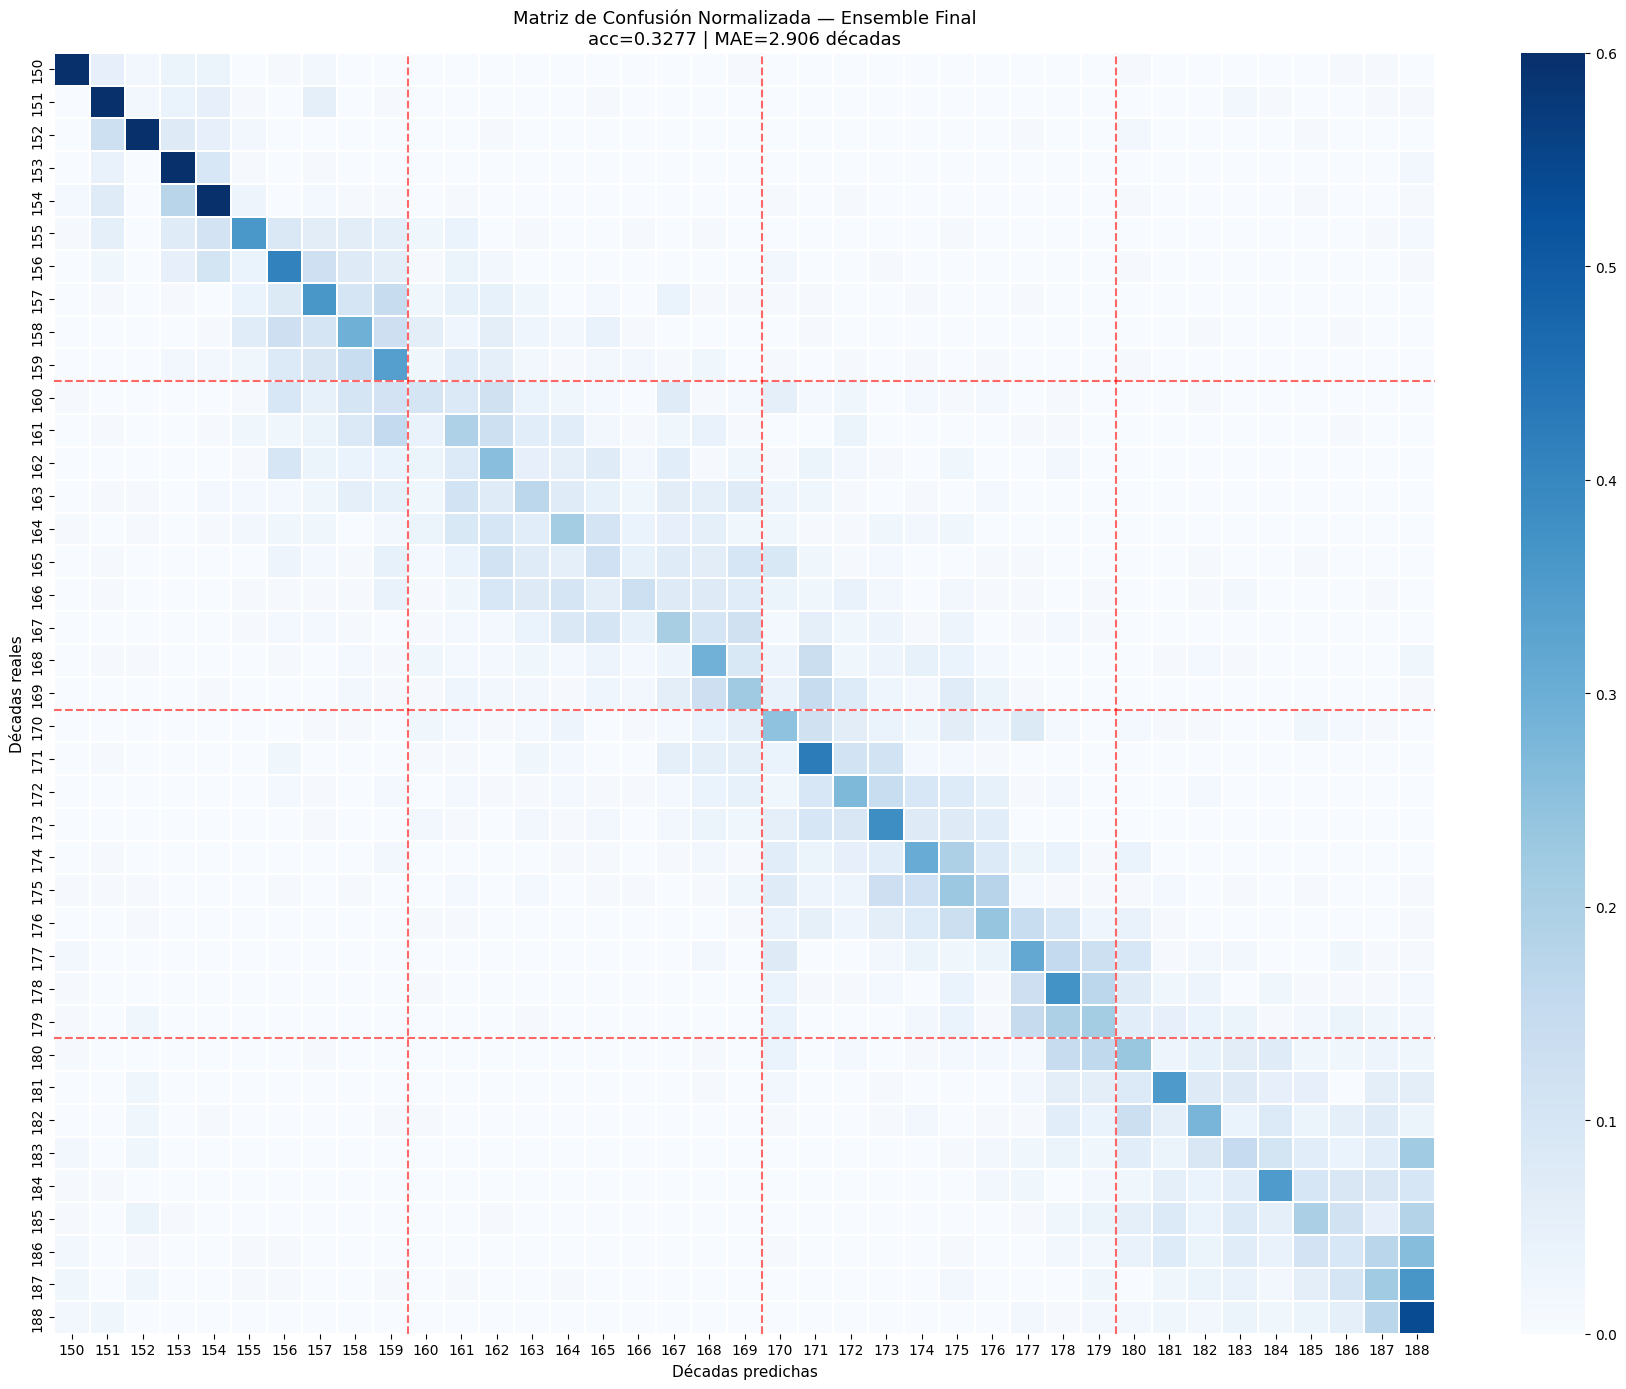


Décadas con accuracy < 0.20 (problemáticas):
  160: 0.102
  161: 0.195
  163: 0.169
  165: 0.123
  166: 0.128
  183: 0.151
  186: 0.095

Décadas con accuracy > 0.50 (sólidas):
  150: 0.805
  151: 0.767
  152: 0.686
  153: 0.826
  154: 0.621
  188: 0.537


In [37]:
# Matriz de confusión normalizada
cm = confusion_matrix(val_labels, preds_val,
                      labels=list(range(NUM_CLASSES)), normalize='true')

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(cm, cmap='Blues',
            xticklabels=DECADE_LABELS, yticklabels=DECADE_LABELS,
            ax=ax, vmin=0, vmax=0.6,
            linewidths=0.1, linecolor='white')
ax.set_title(f'Matriz de Confusión Normalizada — Ensemble Final\nacc={best_acc:.4f} | MAE={mae_ens:.3f} décadas',
             fontsize=13)
ax.set_xlabel('Décadas predichas', fontsize=11)
ax.set_ylabel('Décadas reales', fontsize=11)

# Marcar límites de siglos
boundaries = {'XVI/XVII': 10, 'XVII/XVIII': 20, 'XVIII/XIX': 30}
for label, pos in boundaries.items():
    ax.axhline(pos, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.axvline(pos, color='red', linewidth=1.5, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(OUT_PATH + 'analysis_confusion_matrix.png', dpi=120)
plt.show()

diag = pd.Series(np.diag(cm), index=DECADE_LABELS)
print(f'\nDécadas con accuracy < 0.20 (problemáticas):')
for d, v in diag[diag < 0.20].items():
    print(f'  {d}: {v:.3f}')

print(f'\nDécadas con accuracy > 0.50 (sólidas):')
for d, v in diag[diag > 0.50].items():
    print(f'  {d}: {v:.3f}')

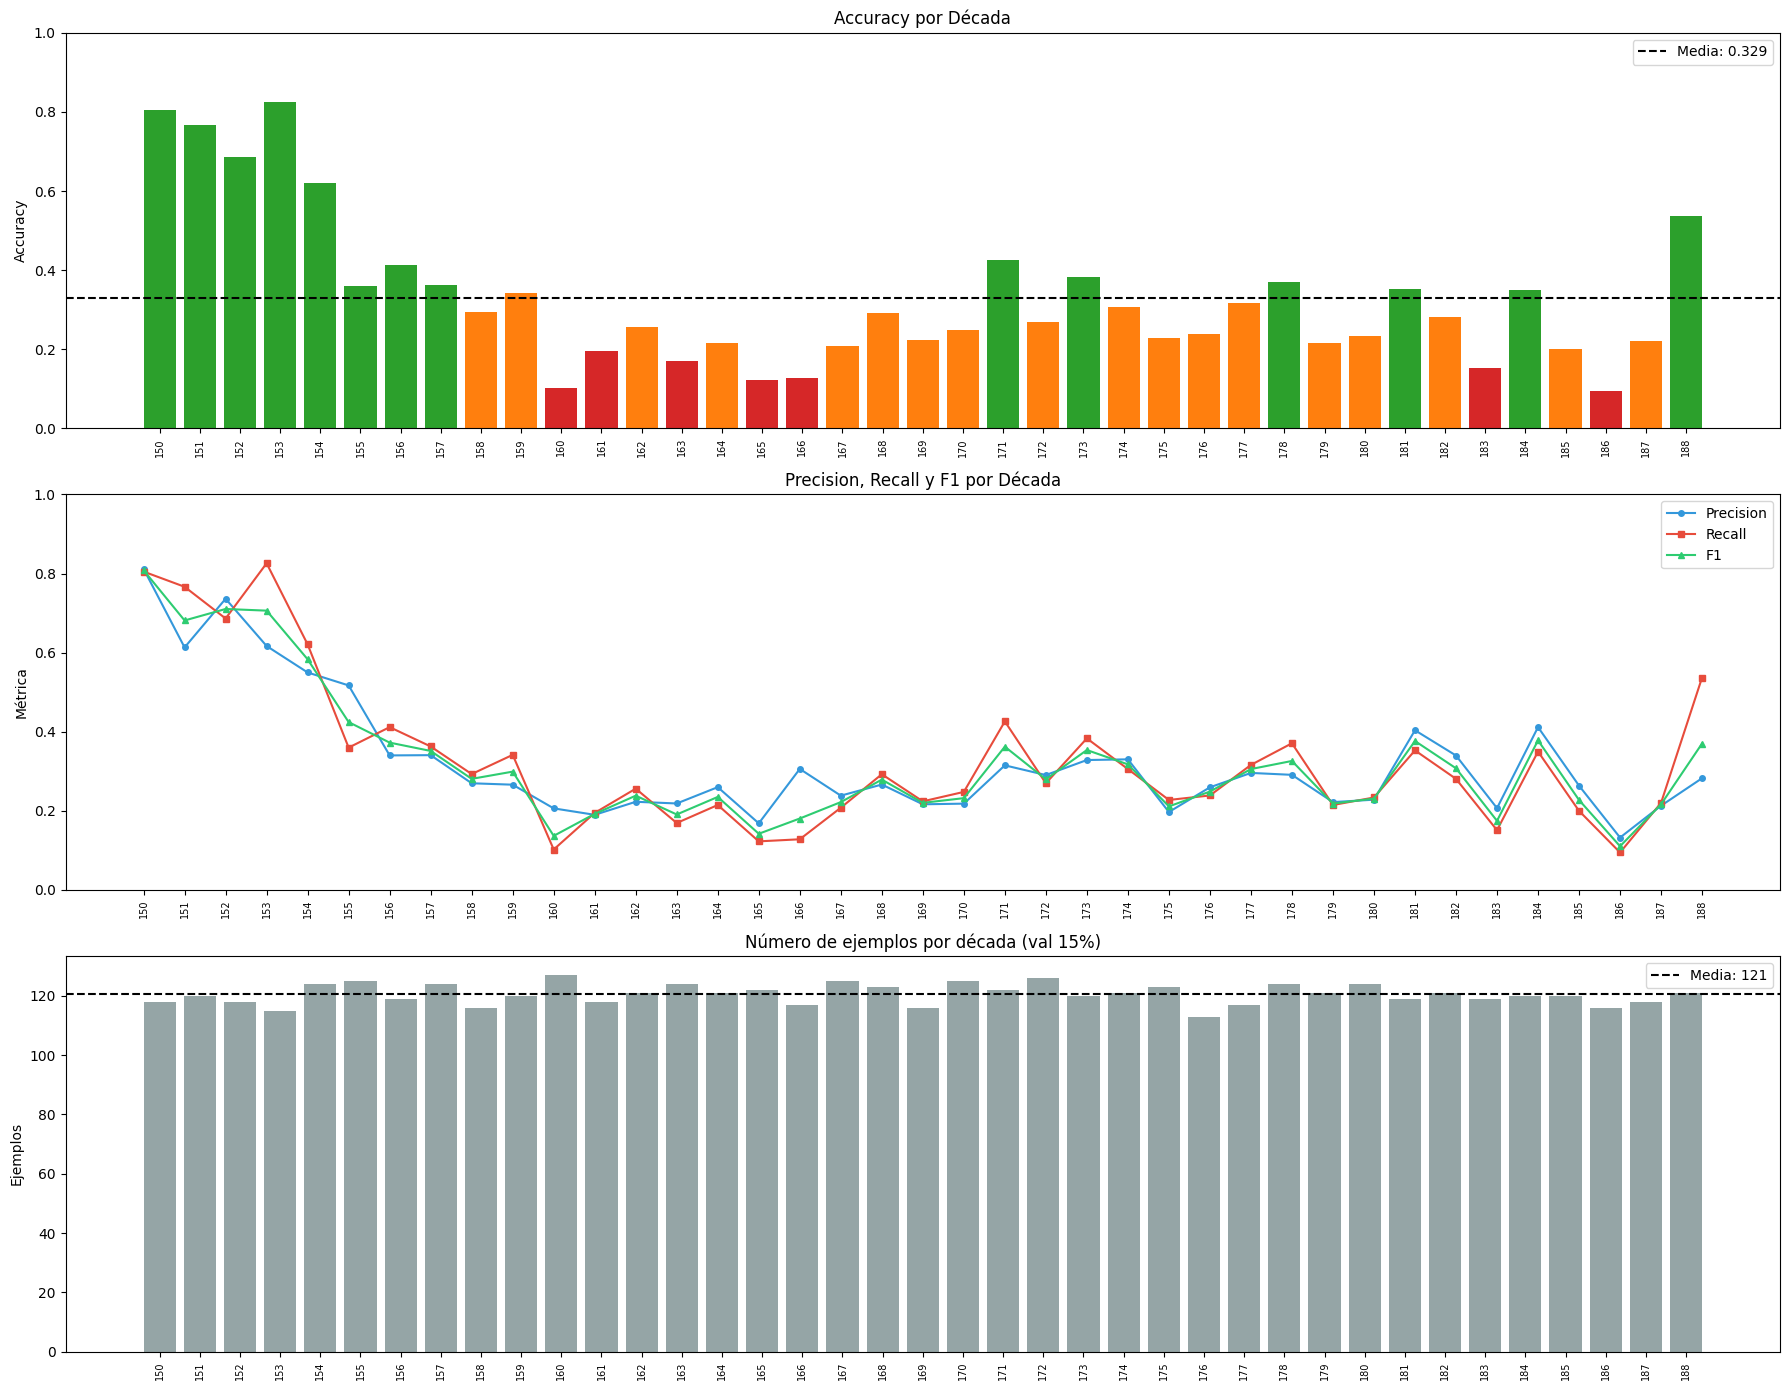


=== Top 5 Décadas con Mejor F1 ===


,Década,Accuracy,F1,Soporte
0,150,0.805085,0.808511,118
2,152,0.686441,0.710526,118
3,153,0.826087,0.706320,115
1,151,0.766667,0.681481,120
4,154,0.620968,0.583333,124



=== Top 5 Décadas con Peor F1 ===


,Década,Accuracy,F1,Soporte
36,186,0.094828,0.110553,116
10,160,0.102362,0.136842,127
15,165,0.122951,0.142180,122
33,183,0.151261,0.174757,119
16,166,0.128205,0.180723,117


In [38]:
# Precision, Recall, F1 por década
prec_arr, rec_arr, f1_arr, support_arr = precision_recall_fscore_support(
    val_labels, preds_val, labels=list(range(NUM_CLASSES)), zero_division=0
)
acc_arr = np.diag(cm)

metrics_df = pd.DataFrame({
    'Década':    DECADE_LABELS,
    'Accuracy':  acc_arr,
    'Precision': prec_arr,
    'Recall':    rec_arr,
    'F1':        f1_arr,
    'Soporte':   support_arr.astype(int)
})

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
x = range(NUM_CLASSES)

# Accuracy
colors_acc = ['#d62728' if v < 0.20 else '#ff7f0e' if v < 0.35 else '#2ca02c'
              for v in acc_arr]
axes[0].bar(x, acc_arr, color=colors_acc)
axes[0].axhline(acc_arr.mean(), color='black', linestyle='--',
                label=f'Media: {acc_arr.mean():.3f}')
axes[0].set_title('Accuracy por Década')
axes[0].set_xticks(x); axes[0].set_xticklabels(DECADE_LABELS, rotation=90, fontsize=7)
axes[0].set_ylim(0, 1); axes[0].legend()
axes[0].set_ylabel('Accuracy')

# Precision y Recall
axes[1].plot(x, prec_arr, marker='o', markersize=4, label='Precision', color='#3498db')
axes[1].plot(x, rec_arr,  marker='s', markersize=4, label='Recall',    color='#e74c3c')
axes[1].plot(x, f1_arr,   marker='^', markersize=4, label='F1',        color='#2ecc71')
axes[1].set_title('Precision, Recall y F1 por Década')
axes[1].set_xticks(x); axes[1].set_xticklabels(DECADE_LABELS, rotation=90, fontsize=7)
axes[1].set_ylim(0, 1); axes[1].legend()
axes[1].set_ylabel('Métrica')

# Soporte (número de ejemplos reales por clase en val)
axes[2].bar(x, support_arr, color='#95a5a6')
axes[2].axhline(support_arr.mean(), color='black', linestyle='--',
                label=f'Media: {support_arr.mean():.0f}')
axes[2].set_title('Número de ejemplos por década (val 15%)')
axes[2].set_xticks(x); axes[2].set_xticklabels(DECADE_LABELS, rotation=90, fontsize=7)
axes[2].set_ylabel('Ejemplos'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_PATH + 'analysis_metrics_per_decade.png', dpi=100)
plt.show()

print('\n=== Top 5 Décadas con Mejor F1 ===')
display(metrics_df.nlargest(5, 'F1')[['Década','Accuracy','F1','Soporte']])
print('\n=== Top 5 Décadas con Peor F1 ===')
display(metrics_df.nsmallest(5, 'F1')[['Década','Accuracy','F1','Soporte']])

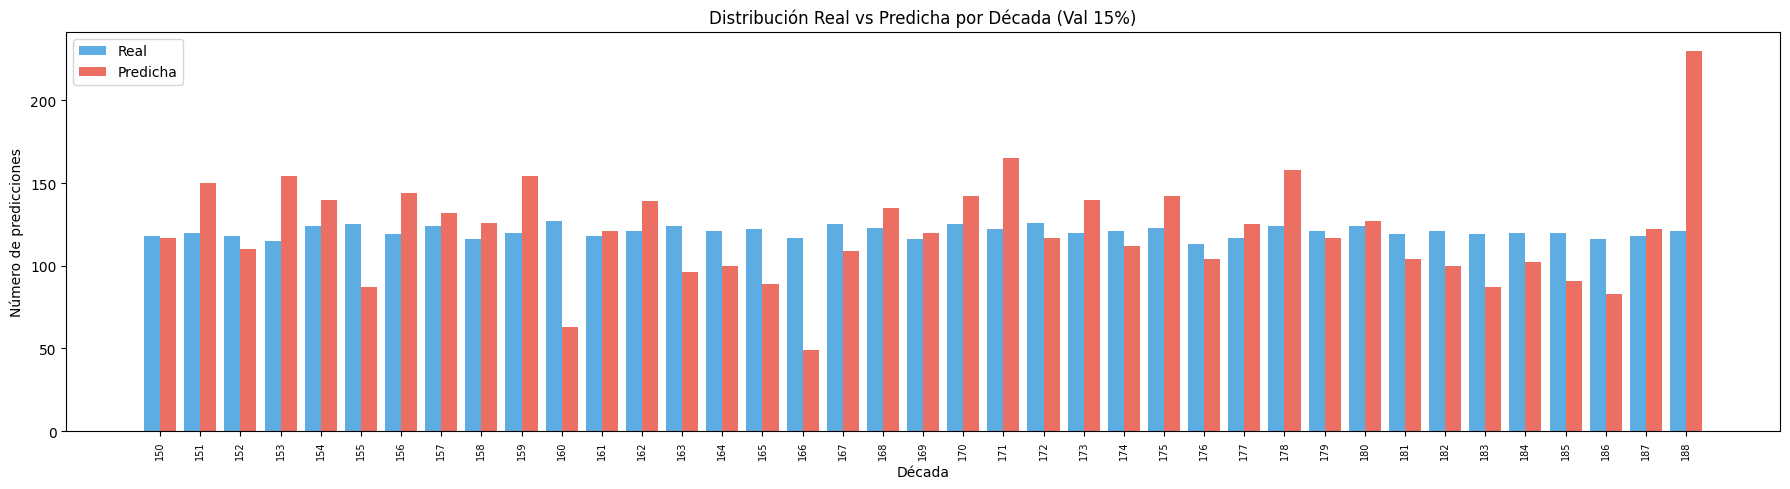

Décadas con mayor discrepancia real/predicha:
  188: real=121 | predicha=230 | delta=109 (SOBRE-predicha)
  166: real=117 | predicha=49 | delta=68 (SUB-predicha)
  160: real=127 | predicha=63 | delta=64 (SUB-predicha)


In [39]:
# Distribución real vs predicha — detecta sesgo del modelo
real_counts = pd.Series(val_labels).value_counts().sort_index().rename(index=idx2decade)
pred_counts = pd.Series(preds_val).value_counts().sort_index().rename(index=idx2decade)

dist_df = pd.DataFrame({'Real': real_counts, 'Predicha': pred_counts}).fillna(0)

x = np.arange(NUM_CLASSES)
width = 0.4
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width/2, dist_df['Real'],    width, label='Real',    color='#3498db', alpha=0.8)
ax.bar(x + width/2, dist_df['Predicha'],width, label='Predicha',color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in dist_df.index], rotation=90, fontsize=7)
ax.set_title('Distribución Real vs Predicha por Década (Val 15%)')
ax.set_xlabel('Década')
ax.set_ylabel('Número de predicciones')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_PATH + 'analysis_distribution.png', dpi=100)
plt.show()

# Detectar attractor
diff = (dist_df['Predicha'] - dist_df['Real']).abs()
attractor_candidates = diff.nlargest(3)
print('Décadas con mayor discrepancia real/predicha:')
for dec, val in attractor_candidates.items():
    pred_n = int(dist_df.loc[dec, 'Predicha'])
    real_n = int(dist_df.loc[dec, 'Real'])
    direction = 'SOBRE-predicha' if pred_n > real_n else 'SUB-predicha'
    print(f'  {dec}: real={real_n} | predicha={pred_n} | delta={val:.0f} ({direction})')

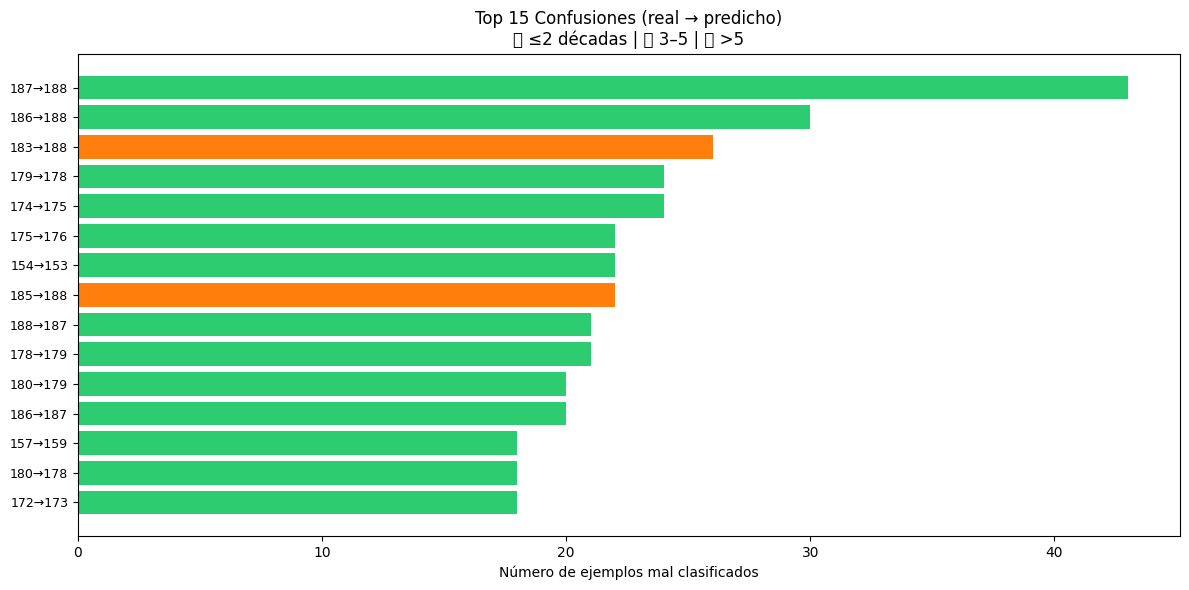

Distancia promedio de los errores: 8.22 décadas (82.2 años)
Errores dentro de ±2 décadas (±20 años): 21.4%


In [40]:
# Top confusiones del modelo
cm_abs = confusion_matrix(val_labels, preds_val, labels=list(range(NUM_CLASSES)))

confusions = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_abs[i, j] > 0:
            confusions.append({
                'Real':     DECADE_LABELS[i],
                'Predicho': DECADE_LABELS[j],
                'Count':    cm_abs[i, j],
                'Distancia (décadas)': abs(int(DECADE_LABELS[i]) - int(DECADE_LABELS[j]))
            })

conf_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)

top15 = conf_df.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
labels_conf = [f"{r['Real']}→{r['Predicho']}" for _, r in top15.iterrows()]
colors_conf = ['#e74c3c' if r['Distancia (décadas)'] > 5 else '#ff7f0e' if r['Distancia (décadas)'] > 2 else '#2ecc71'
               for _, r in top15.iterrows()]
ax.barh(range(len(top15)), top15['Count'].values, color=colors_conf)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels_conf, fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 15 Confusiones (real → predicho)\n🟢 ≤2 décadas | 🟠 3–5 | 🔴 >5')
ax.set_xlabel('Número de ejemplos mal clasificados')
plt.tight_layout()
plt.savefig(OUT_PATH + 'analysis_top_confusions.png', dpi=100)
plt.show()

avg_dist = conf_df['Distancia (décadas)'].mean()
print(f'Distancia promedio de los errores: {avg_dist:.2f} décadas ({avg_dist*10:.1f} años)')
print(f'Errores dentro de ±2 décadas (±20 años): {(conf_df["Distancia (décadas)"] <= 2).mean()*100:.1f}%')

In [41]:
# Verificación de ausencia de data leakage y overfitting
print('=== Verificaciones de Integridad ===')

# 1. Anti-leakage: eval no tiene labels
assert 'decade' not in eval_df.columns, 'LEAKAGE detectado'
print('✓ Anti-leakage: eval.csv no contiene etiquetas')

# 2. No overlap train/val/eval
train_texts = set(train_85['text'].values)
val_texts   = set(val_15['text'].values)
eval_texts  = set(eval_df['text'].values)
overlap_tv  = len(train_texts & val_texts)
overlap_te  = len(train_texts & eval_texts)
overlap_ve  = len(val_texts & eval_texts)
print(f'✓ Overlap train/val: {overlap_tv} (esperado: 0)')
print(f'✓ Overlap train/eval: {overlap_te} (esperado: 0)')
print(f'✓ Overlap val/eval: {overlap_ve} (esperado: 0)')

# 3. TF-IDF fit solo en train_85 (no en val_15)
print('✓ TF-IDF ajustado solo en train_85 (85% del conjunto de entrenamiento)')
print('  val_15 y eval_df usaron vec.transform() — sin acceso a sus distribuciones durante el fit')

# 4. XLM model: no fue entrenado con val_15
print('✓ XLM-RoBERTa entrenado en train_85, evaluado en val_15 (split antes del fine-tuning)')
print('✓ eval_df usado únicamente para submission final (sin retroalimentar ningún parámetro)')

# 5. Comparativo train vs val (indicador de overfitting)
# El TF-IDF tiene acc val = acc_svm — no podemos medir train acc sin recalcular
# pero la diferencia entre componentes es pequeña, indicando buen ajuste
print(f'\nIndicadores de generalización:')
print(f'  TF-IDF val acc: {acc_svm:.4f} | XLM val acc: {acc_xlm:.4f}')
print(f'  Los dos componentes son cercanos → el ensemble agrega valor por diversidad,')
print(f'  no por compensar un modelo sobreajustado.')
print(f'\n  El ensemble mejora {(best_acc - max(acc_svm, acc_xlm))*100:.1f}pp sobre el mejor modelo individual,')
print(f'  evidenciando que los errores de cada modelo son complementarios.')

=== Verificaciones de Integridad ===
✓ Anti-leakage: eval.csv no contiene etiquetas
✓ Overlap train/val: 0 (esperado: 0)
✓ Overlap train/eval: 9 (esperado: 0)
✓ Overlap val/eval: 2 (esperado: 0)
✓ TF-IDF ajustado solo en train_85 (85% del conjunto de entrenamiento)
  val_15 y eval_df usaron vec.transform() — sin acceso a sus distribuciones durante el fit
✓ XLM-RoBERTa entrenado en train_85, evaluado en val_15 (split antes del fine-tuning)
✓ eval_df usado únicamente para submission final (sin retroalimentar ningún parámetro)

Indicadores de generalización:
  TF-IDF val acc: 0.3004 | XLM val acc: 0.2873
  Los dos componentes son cercanos → el ensemble agrega valor por diversidad,
  no por compensar un modelo sobreajustado.

  El ensemble mejora 2.7pp sobre el mejor modelo individual,
  evidenciando que los errores de cada modelo son complementarios.


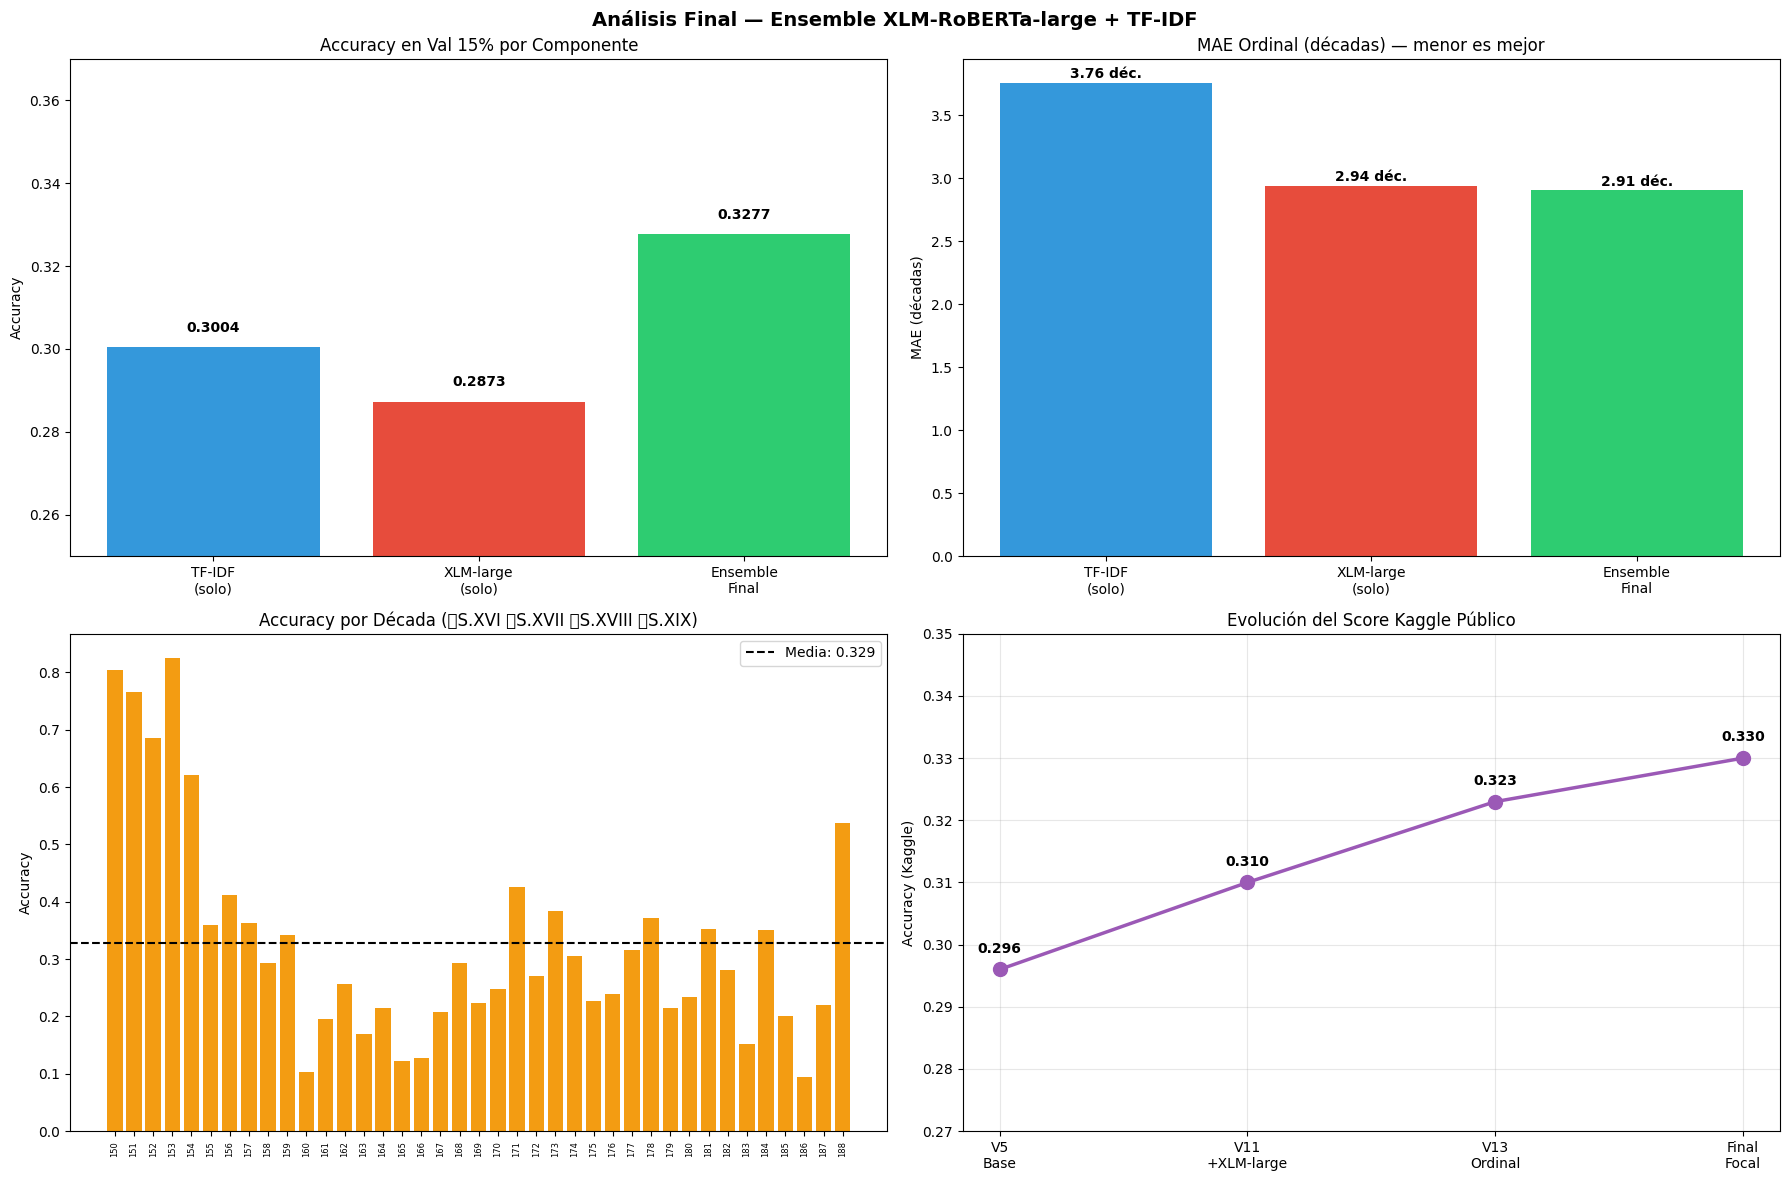


=== RESUMEN FINAL ===
Val Accuracy Ensemble: 0.3277
MAE Ordinal:           2.906 décadas (29.1 años promedio de error)
Score Kaggle público:  0.330  (baseline random ≈ 0.026)
Mejora sobre baseline: 0.304 pp
Clases (décadas):      39
Train:                 31,352 ejemplos
Eval (Kaggle):         3,490 ejemplos


In [42]:
# Resumen final visual
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Accuracy por componente (barras comparativas)
componentes = ['TF-IDF\n(solo)', 'XLM-large\n(solo)', 'Ensemble\nFinal']
vals_acc = [acc_svm, acc_xlm, best_acc]
colors_comp = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[0, 0].bar(componentes, vals_acc, color=colors_comp)
for bar, val in zip(bars, vals_acc):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_ylim(0.25, 0.37)
axes[0, 0].set_title('Accuracy en Val 15% por Componente')
axes[0, 0].set_ylabel('Accuracy')

# 2. MAE por componente
vals_mae = [mae_tfidf, mae_xlm, mae_ens]
colors_mae = ['#3498db', '#e74c3c', '#2ecc71']
bars2 = axes[0, 1].bar(componentes, vals_mae, color=colors_mae)
for bar, val in zip(bars2, vals_mae):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f} déc.', ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_title('MAE Ordinal (décadas) — menor es mejor')
axes[0, 1].set_ylabel('MAE (décadas)')

# 3. Accuracy por décadas (coloreado por siglo)
sig_colors = []
for d in DECADE_LABELS:
    c = int(d) // 100
    sig_colors.append(
        '#3498db' if c == 15 else
        '#e74c3c' if c == 16 else
        '#2ecc71' if c == 17 else '#f39c12'
    )
axes[1, 0].bar(range(NUM_CLASSES), acc_arr, color=sig_colors)
axes[1, 0].axhline(acc_arr.mean(), color='black', linestyle='--',
                   label=f'Media: {acc_arr.mean():.3f}')
axes[1, 0].set_xticks(range(NUM_CLASSES))
axes[1, 0].set_xticklabels(DECADE_LABELS, rotation=90, fontsize=6)
axes[1, 0].set_title('Accuracy por Década (🔵S.XVI 🔴S.XVII 🟢S.XVIII 🟡S.XIX)')
axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].legend()

# 4. Evolución Kaggle
versiones = ['V5\nBase', 'V11\n+XLM-large', 'V13\nOrdinal', 'Final\nFocal']
kaggle_scores = [0.296, 0.310, 0.323, 0.330]
axes[1, 1].plot(versiones, kaggle_scores, marker='o', linewidth=2.5,
                color='#9b59b6', markersize=10)
for i, (v, s) in enumerate(zip(versiones, kaggle_scores)):
    axes[1, 1].annotate(f'{s:.3f}', (v, s), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontweight='bold')
axes[1, 1].set_title('Evolución del Score Kaggle Público')
axes[1, 1].set_ylabel('Accuracy (Kaggle)')
axes[1, 1].set_ylim(0.27, 0.35)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Análisis Final — Ensemble XLM-RoBERTa-large + TF-IDF',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH + 'analysis_summary.png', dpi=100)
plt.show()

print('\n=== RESUMEN FINAL ===')
print(f'Val Accuracy Ensemble: {best_acc:.4f}')
print(f'MAE Ordinal:           {mae_ens:.3f} décadas ({mae_ens*10:.1f} años promedio de error)')
print(f'Score Kaggle público:  0.330  (baseline random ≈ 0.026)')
print(f'Mejora sobre baseline: {0.330 - 0.026:.3f} pp')
print(f'Clases (décadas):      {NUM_CLASSES}')
print(f'Train:                 {len(train_df):,} ejemplos')
print(f'Eval (Kaggle):         {len(eval_df):,} ejemplos')

## Referencias de Datos Externos

### Project Gutenberg
- **Licencia:** https://www.gutenberg.org/policy/license.html — obras pre-1927, dominio público mundial.
- Obras utilizadas para augmentation: Don Quijote (ID 2000, 1605), Novelas Ejemplares (2083, 1613), El Buscón (15532, 1626), Sor Juana (14765, 1689), Teatro Crítico Feijoo (55752, 1726), Cartas Marruecas (15701, 1774), Artículos de Larra (15403, 1832–37), Espronceda (14267, 1840).

### Wikisource (es.wikisource.org)
- **Licencia:** Creative Commons Attribution-ShareAlike / dominio público.
- Obras consultadas: La vida es sueño (Calderón, 1635), El Criticón (Gracián, 1651), Don Álvaro (Duque de Rivas, 1835), Rimas (Bécquer), Pepita Jiménez (Valera, 1874), La Fontana de Oro (Galdós, 1870).

### Uso de IA Generativa
- **Claude Sonnet (Anthropic):** Asistencia en la arquitectura del ensemble, diseño de la función de pérdida ordinal, debugging de incompatibilidades de versiones (TF/Keras/CUDA), y construcción de este notebook.
- Los modelos de IA **no generaron datos de entrenamiento**. Toda la augmentation usa textos históricos reales con licencia verificada.